# Exploratory data analysis
Introduction to exploratory data analysis (EDA).

EDA is an approach to analyzing datasets to summarize their main characteristics, often with visual methods. EDA is used for seeing what the data can tell us before the modeling task [(source 1)](https://chartio.com/learn/data-analytics/what-is-exploratory-data-analysis/). It is used to explore the data, find different patterns, relations, and anomalies in the data using some statistical graphs and other visualization techniques, and possibly formulate hypotheses that could lead to new data collection and experiments [(source 2)](https://www.analyticsvidhya.com/blog/2021/08/how-to-perform-exploratory-data-analysis-a-guide-for-beginners/). More specifically, EDA enables analysts to:
1. get maximum insights from a data set
2. uncover underlying structure
3. extract important variables from the dataset
4. detect outliers and anomalies (if any)
5. test underlying assumptions
6. determine the optimal factor settings

## EDA steps and tools
Practical steps in conducting EDA and frequently used EDA tools.
Based on *pandas2020-main.Sales_Analysis_Pandas_P3_tutorial.ipynb* and *pandas2020-main.TED_Talks_Pandas_P3_tutorial.ipynb*.


Based on [this](https://stackoverflow.com/a/22149930/1899061), in all computations, `axis=...` refers to the axis **along which** the computation is done. By default, `axis=0`. This is consistent with the `numpy.mean` usage when axis is specified explicitly (in `numpy.mean`, `axis==None` by default, which computes the mean value over the flattened array), in which `axis=0` along the rows (namely, index in pandas), and `axis=1` along the columns.
Note also that that `axis=0` indicates aggregating along rows and `axis=1` indicates aggregating along columns. This is consistent with how we index into a dataframe. In `df.iloc[<row>, <column>]`, `<row>` is in index position 0 and `<column>` is in index position 1. For added clarity, one may choose to specify `axis='index'` (instead of `axis=0`) or `axis='columns'` (instead of `axis=1`).
**But**, `axis=0` means each row as a bulk - we manipulate a `pd.DataFrame` inter-row, instead of within-row. Likewise, 1 means each column as a bulk, i.e. we manipulate a `pd.DataFrame` inter-column instead of within-column. For example, `<pd.df>.drop("A", axis=1)` will drop a whole column.

### Reading the dataset
- `pd.read_csv()`

### Initial examination and adaptations
- `<pd.df>.shape`, `<pd.df>.head()`, `<pd.df>.tail()`, `<pd.df>.sample()`, `<pd.df>.dtypes`, `<pd.df>.info()`, `<pd.df>.describe()`
- `<pd.df>.loc[...]`, `<pd.df>.iloc[...]` - examine individual cells, columns, rows
    - `loc` works with conditions and column names, `iloc` with numerical indices
    - in both `loc` and `iloc`, multiple columns can be specified as a list of column names, and `:` in each index position means 'all'
    - in `iloc`, both index positions can be specified as lists of numeric values
- `<pd.df>.columns`, `<pd.df>.columns.values`, `<pd.df>.columns.values.tolist()` (or `<pd.df>.columns.values.to_list()`), `<pd.df>.values`
- `<pd.df>.rename({'<column_1 old name>':'<column_1 new name>', '<column_2 old name>':'<column_2 new name>', ...}, axis='columns')`, `<pd.df>.columns = ['<column_1 name>', '<column_2 name>', ...]` (change the names of all columns in <pd.df>)
- `ast.literal_eval()` (using Python's *ast* module to transform a string into a literal value, a list, a tuple or any other container object)

### Missing values and value counts
- `sb.heatmap()`, e.g. `sb.heatmap(<pd.df>.isna(),cbar=False,cmap='viridis')` ([example](https://www.analyticsvidhya.com/blog/2021/08/how-to-perform-exploratory-data-analysis-a-guide-for-beginners/))
- `<pd.df>.isna()` (`<pd.df>.isnull()`), `<pd.df>.isna().sum()` (`<pd.df>.isnull().sum`) ([example](https://www.analyticsvidhya.com/blog/2021/08/how-to-perform-exploratory-data-analysis-a-guide-for-beginners/))
- `<pd.df>['<column>'].value_counts()` (shows only the rows without NAs (default: dropna=True), check shape)
- `<pd.df>['<column>'].value_counts(normalize=True)` (show proportions, rather than frequencies)
- `<pd.Series>.dropna(how='all'/'any', inplace=True)` (return a new `<pd.Series>` object with missing values removed)

The `cmap` parameter of `sb.heatmap()` denotes a [Matplotlib colormap](https://matplotlib.org/stable/tutorials/colors/colormaps.html#classes-of-colormaps) (`viridis`, `cividis`, `tab20`, `winter`, `BuPu_r`, `ocean`,...).

### Examining individual data items, rows and columns
- `<pd.df>.sample()`
- Simple indexing and fancy indexing: `<pd.df>.iloc[]`, `<pd.df>.loc[]`
- `<pd.df>.index`, `<pd.df>.index[<from>:<to>]`, `<pd.df>.reset_index(drop=True, inplace=True)`
- Indexing using list of values: `<pd.df>.loc[<pd.df>.<column>.isin(<list of values>)]` (select those observations where the value of `<column>` is in the `<list of values>`)
- Indexing in data stats: `<pd.df>.describe().loc['50%', '<column_name>']` (select the median of `<column_name>` from the `<pd.df>` stats computed by `describe()`)

### Grouping and sorting data
- `<pd.df>['<column>'].unique()`, `<pd.df>['<column>'].nunique()`
- `<pd.df>['<column>'].groupby()`, `<pd.df>['<column>'].groupby().get_group()`
- `<pd.df>['<column>'].value_counts()`, `<pd.df>['<column>'].value_counts().sort_index()`, `<pd.df>['<column>'].value_counts().sort_index(inplace=True)`
- `<pd.df>.sort_values(by='<column name>', ascending=False/True)`
- `<pd.df>.groupby('<column>').<another column>.<f()>.sort_values(ascending=False)` (aggregate using function `f()`, e.g. `mean()`)
- `<pd.df>.groupby('<column>').<another column>.agg(['<f1 name>', '<f2 name>', ...])` (aggregate using multiple functions, e.g. `mean()`, `count()`,...)

If `sort_values()` is used after `agg(['f1 name>', '<f2 name>', ...])` (`agg(['<f1 name>', '<f2 name>', ...]).sort_values(by='<f name>', ascending=False)`), it must be passed one positional argument (`by='<f name>'`) before the optional `ascending=False`.


### Data transformations
- `<pd.df>.describe()`
- `pd.to_numeric(<pd.DataFrame object>['<column name>'], errors='coerce')`, `pd.DataFrame.to_numpy()`, `pd.Series.to_numpy()`, `pd.to_datetime()`, ...
- `<pd.df>.<column>.apply(<f_name>)` (apply the <f_name> function to all elements of each element of the `<column>`; for example, each element of the `<column>` can be a list of other elements)


### Exploring correlations
Explore correlations between the (numerical) columns. 
- `sb.heatmap()`
- [Example](https://www.analyticsvidhya.com/blog/2021/08/how-to-perform-exploratory-data-analysis-a-guide-for-beginners/)

### Data visualization
Plot some bargraphs, scatterplots, boxplots,...
- [Example](https://www.analyticsvidhya.com/blog/2021/08/how-to-perform-exploratory-data-analysis-a-guide-for-beginners/)

### Other
[Other interesting ideas and different ways of using the things from above](https://realpython.com/pandas-python-explore-dataset/#exploring-your-dataset) (see the rest from [that article](https://realpython.com/pandas-python-explore-dataset/) as well).

## Import and configure packages
The `%run` magic might not work well in DataSpell, thus the following `import` statements are copied here from *import_packages.ipynb*:

In [ ]:
%run "../notebooks/import_packages.ipynb"

In [2]:
%matplotlib inline

import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
plt.style.use('classic')            # Matplotlib stylesheet reference: https://matplotlib.org/stable/gallery/style_sheets/style_sheets_reference.html
import pandas as pd
import seaborn as sb

## Introducing The Beatles dataset

*The Beatles songs dataset, v1.csv* - complete raw dataset, located in the *data* folder.

### Read the *csv* file containing one of the available datasets describing The Beatles songs
`pd.read_csv()` returns a `pd.DataFrame` object.

As for specifying the path of the dataset properly, see [this](https://stackoverflow.com/questions/35384358/how-to-open-my-files-in-data-folder-with-pandas-using-relative-path) (more specifically, **both** [this](https://stackoverflow.com/a/35384414/1899061) and [this](https://stackoverflow.com/a/43600253/1899061)).

In [2]:
# Get the songs as a pd.DataFrame object from 'data/The Beatles songs dataset, v1.csv',
# or from '../data/The Beatles songs dataset, v1.csv',
# or '../../data/The Beatles songs dataset, v1.csv',
# or ..., 
# depending on where the csv file is located
songs = pd.read_csv('../data/The Beatles songs dataset, v1.csv')
songs

# If an int column contains NaN values, read_csv() sets all values to float values, because NaN are internally
# represented as float values. To read the int columns as int values and still preserve NaN values where they 
# exist, see this: https://stackoverflow.com/a/72323514. 
# The trick is: df = pd.read_csv('file.csv', dtype={'a': 'Int32', 'b': 'Int32'}), assuming that 'a' and 'b' 
# columns contain int and NaN values.

,Title,Year,Album.debut,Duration,Other.releases,Genre,Songwriter,Lead.vocal,Top.50.Billboard
0,12-Bar Original,1965,Anthology 2,174,0,Blues,"Lennon, McCartney, Harrison and Starkey",NaN,-1
1,A Day in the Life,1967,Sgt. Pepper's Lonely Hearts Club Band,335,12,"Psychedelic Rock, Art Rock, Pop/Rock",Lennon and McCartney,Lennon and McCartney,-1
2,A Hard Day's Night,1964,UK: A Hard Day's Night US: 1962-1966,152,35,"Rock, Electronic, Pop/Rock",Lennon,"Lennon, with McCartney",8
3,A Shot of Rhythm and Blues,1963,Live at the BBC,104,0,"R&B, Pop/Rock",Thompson,Lennon,-1
4,A Taste of Honey,1963,UK: Please Please Me US: The Early Beatles,163,29,"Pop/Rock, Jazz, Stage&Screen","Scott, Marlow",McCartney,-1
...,...,...,...,...,...,...,...,...,...
305,You're Going to Lose That Girl,1965,Help!,140,6,"Rock, Pop/Rock",Lennon,Lennon,-1
306,You've Got to Hide Your Love Away,1965,Help!,131,12,FolkPop/Rock,Lennon,Lennon,-1
307,You've Really Got a Hold on Me,1963,UK: With the Beatles US: The Beatles Second Album,182,2,"Soul, Pop/Rock",Robinson,Lennon and Harrison,-1
308,Young Blood,1963,Live at the BBC,116,0,Pop/Rock,"Leiber, Stoller",Harrison,-1


### Explore the dataset (first steps)

##### Initial examination and adaptations
- `<pd.df>.shape`, `<pd.df>.head()`, `<pd.df>.tail()`, `<pd.df>.sample()`, `<pd.df>.dtypes`, `<pd.df>.info()`, `<pd.df>.describe()`
- `<pd.df>.loc[...]`, `<pd.df>.iloc[...]` - examine individual cells, columns, rows
    - `loc` works with conditions and column names, `iloc` with numerical indices
    - in both `loc` and `iloc`, multiple columns can be specified as a list of column names, and `:` in each index position means 'all'
    - in `iloc`, both index positions can be specified as lists of numeric values
- `<pd.df>.columns`, `<pd.df>.columns.values`, `<pd.df>.columns.values.tolist()` (or `<pd.df>.columns.values.to_list()`), `<pd.df>.values`
- `<pd.df>.rename({'<column_1 old name>':'<column_1 new name>', '<column_2 old name>':'<column_2 new name>', ...}, axis='columns')`, `<pd.df>.columns = ['<column_1 name>', '<column_2 name>', ...]` (change the names of all columns in <pd.df>)
- `ast.literal_eval()` (using Python's *ast* module to transform a string into a literal value, a list, a tuple or any other container object)

###### A sneak peek into the dataset
- `<pd.df>.shape`, `<pd.df>.head()`, `<pd.df>.tail()`, `<pd.df>.sample()`, `<pd.df>.dtypes`, **<u>`<pd.df>.info()`**</u>, `<pd.df>.describe()` (shows descriptive statistics for numerical columns only).

When calling `display()` on a method like `<pd.df>.head()`, `<pd.df>.tail()` and `<pd.df>.sample()`, only a certain default number of columns is displayed. To display *all* columns, use `pd.set_option('display.max_columns', None)` first. To display `<n>` columns, use `pd.set_option('display.max_columns', <n>)` first. 

In [14]:
# print(songs.shape)
# display(songs.head())
songs.shape
songs.head()
songs.tail()
songs.sample(10)
songs.dtypes
songs.info()
songs.describe()

<class 'pandas.DataFrame'>
RangeIndex: 310 entries, 0 to 309
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Title             310 non-null    str  
 1   Year              310 non-null    int64
 2   Album.debut       288 non-null    str  
 3   Duration          310 non-null    int64
 4   Other.releases    310 non-null    int64
 5   Genre             306 non-null    str  
 6   Songwriter        310 non-null    str  
 7   Lead.vocal        302 non-null    str  
 8   Top.50.Billboard  310 non-null    int64
dtypes: int64(4), str(5)
memory usage: 21.9 KB


,Year,Duration,Other.releases,Top.50.Billboard
count,310.000000,310.000000,310.000000,310.000000
mean,1965.429032,159.645161,10.422581,3.158065
std,2.721090,53.995774,10.197665,11.215635
min,1958.000000,23.000000,0.000000,-1.000000
25%,1963.000000,133.000000,0.000000,-1.000000
50%,1965.000000,150.000000,9.000000,-1.000000
75%,1968.000000,172.750000,16.000000,-1.000000
max,1980.000000,502.000000,56.000000,50.000000


###### Columns
- `<pd.df>.columns`, `<pd.df>.columns.values`, `<pd.df>.columns.values.tolist()` (or `<pd.df>.columns.values.to_list()`), `<pd.df>.values`

Show the columns of the `songs` object (which is a `pd.DataFrame` object).

In [20]:
# Get the columns as a pd.Index object, using <pd.df>.columns
songs.columns
# Get the columns as a list, using list(<pd.df>.columns)
songs.columns.tolist()
# Get the columns as a list, using <pd.df>.columns.tolist() or <pd.df>.columns.to_list()
songs.columns.to_list()
# Get the columns as a numpy.ndarray object, using <pd.df>.columns.values or np.array(<pd.df>.columns)
songs.columns.values
np.array(songs.columns)
# Get the values of all items in the dataset as a numpy.ndarray of sequences of the values in each item, 
# using <pd.df>.values (the type of both the encompassing and the encompassed sequences is numpy.ndarray)
songs.values

array([['12-Bar Original', 1965, 'Anthology 2', ...,
        'Lennon, McCartney, Harrison and Starkey', nan, -1],
       ['A Day in the Life', 1967,
        "Sgt. Pepper's Lonely Hearts Club Band", ...,
        'Lennon and McCartney', 'Lennon and McCartney', -1],
       ["A Hard Day's Night", 1964,
        "UK: A Hard Day's Night US: 1962-1966", ..., 'Lennon',
        'Lennon, with McCartney', 8],
       ...,
       ["You've Really Got a Hold on Me", 1963,
        'UK: With the Beatles US: The Beatles Second Album', ...,
        'Robinson', 'Lennon and Harrison', -1],
       ['Young Blood', 1963, 'Live at the BBC', ..., 'Leiber, Stoller',
        'Harrison', -1],
       ['Your Mother Should Know', 1967, 'Magical Mystery Tour', ...,
        'McCartney', 'McCartney', -1]], shape=(310, 9), dtype=object)

###### Renaming columns
- `<pd.df>.rename(columns={'<column_1 old name>':'<column_1 new name>', '<column_2 old name>':'<column_2 new name>', ...}, inplace=True)`, or
- `<pd.df>.rename({'<column_1 old name>':'<column_1 new name>', '<column_2 old name>':'<column_2 new name>', ...}, axis='columns', inplace=True)`;
- `<pd.df>.columns = ['<column_1 name>', '<column_2 name>', ...]` (change the names of all columns in `<pd.df>`)

In [29]:
# Rename the names of some columns
# # songs.columns
# songs.rename(columns={'Album.debut': 'Album debut', 'Lead.vocal': 'Lead vocal'}, inplace=True)
# songs
# Rename these columns back to their original names
songs.rename(columns={'Album debut': 'Album.debut', 'Lead vocal': 'Lead.vocal'}, inplace=True)
songs

,Title,Year,Album.debut,Duration,Other.releases,Genre,Songwriter,Lead.vocal,Top.50.Billboard
0,12-Bar Original,1965,Anthology 2,174,0,Blues,"Lennon, McCartney, Harrison and Starkey",NaN,-1
1,A Day in the Life,1967,Sgt. Pepper's Lonely Hearts Club Band,335,12,"Psychedelic Rock, Art Rock, Pop/Rock",Lennon and McCartney,Lennon and McCartney,-1
2,A Hard Day's Night,1964,UK: A Hard Day's Night US: 1962-1966,152,35,"Rock, Electronic, Pop/Rock",Lennon,"Lennon, with McCartney",8
3,A Shot of Rhythm and Blues,1963,Live at the BBC,104,0,"R&B, Pop/Rock",Thompson,Lennon,-1
4,A Taste of Honey,1963,UK: Please Please Me US: The Early Beatles,163,29,"Pop/Rock, Jazz, Stage&Screen","Scott, Marlow",McCartney,-1
...,...,...,...,...,...,...,...,...,...
305,You're Going to Lose That Girl,1965,Help!,140,6,"Rock, Pop/Rock",Lennon,Lennon,-1
306,You've Got to Hide Your Love Away,1965,Help!,131,12,FolkPop/Rock,Lennon,Lennon,-1
307,You've Really Got a Hold on Me,1963,UK: With the Beatles US: The Beatles Second Album,182,2,"Soul, Pop/Rock",Robinson,Lennon and Harrison,-1
308,Young Blood,1963,Live at the BBC,116,0,Pop/Rock,"Leiber, Stoller",Harrison,-1


###### Rearranging columns
- `<pd.df> = <pd.df>[['<col to be the first>', 'col to be the second'...etc.]]`
- `column_names = ['<col to be the first>', 'col to be the second'...etc.]`, `<pd.df> = <pd.df>.reindex(columns=column_names)`

In [32]:
# songs.columns
columns = ['Title', 'Album.debut', 'Year', 'Duration', 'Other.releases', 'Genre', 'Songwriter', 'Lead.vocal', 'Top.50.Billboard']
songs.reindex(columns=columns)

,Title,Album.debut,Year,Duration,Other.releases,Genre,Songwriter,Lead.vocal,Top.50.Billboard
0,12-Bar Original,Anthology 2,1965,174,0,Blues,"Lennon, McCartney, Harrison and Starkey",NaN,-1
1,A Day in the Life,Sgt. Pepper's Lonely Hearts Club Band,1967,335,12,"Psychedelic Rock, Art Rock, Pop/Rock",Lennon and McCartney,Lennon and McCartney,-1
2,A Hard Day's Night,UK: A Hard Day's Night US: 1962-1966,1964,152,35,"Rock, Electronic, Pop/Rock",Lennon,"Lennon, with McCartney",8
3,A Shot of Rhythm and Blues,Live at the BBC,1963,104,0,"R&B, Pop/Rock",Thompson,Lennon,-1
4,A Taste of Honey,UK: Please Please Me US: The Early Beatles,1963,163,29,"Pop/Rock, Jazz, Stage&Screen","Scott, Marlow",McCartney,-1
...,...,...,...,...,...,...,...,...,...
305,You're Going to Lose That Girl,Help!,1965,140,6,"Rock, Pop/Rock",Lennon,Lennon,-1
306,You've Got to Hide Your Love Away,Help!,1965,131,12,FolkPop/Rock,Lennon,Lennon,-1
307,You've Really Got a Hold on Me,UK: With the Beatles US: The Beatles Second Album,1963,182,2,"Soul, Pop/Rock",Robinson,Lennon and Harrison,-1
308,Young Blood,Live at the BBC,1963,116,0,Pop/Rock,"Leiber, Stoller",Harrison,-1


In [ ]:
# Save the modified dataset
songs.to_csv('../data/The Beatles songs dataset, v2.csv', index=False)

##### Missing values and value counts
- `sb.heatmap()`, e.g. `sb.heatmap(<pd.df>.isna(),cbar=False,cmap='viridis')` ([example](https://www.analyticsvidhya.com/blog/2021/08/how-to-perform-exploratory-data-analysis-a-guide-for-beginners/))
- `<pd.df>.isna()` (`<pd.df>.isnull()`), `<pd.df>.isna().sum()` (`<pd.df>.isnull().sum()`) ([example](https://www.analyticsvidhya.com/blog/2021/08/how-to-perform-exploratory-data-analysis-a-guide-for-beginners/))
- `<pd.df>['<column>'].value_counts()` (shows only the rows without NAs (default: dropna=True), check shape)
- `<pd.df>['<column>'].value_counts(normalize=True)` (show proportions, rather than frequencies)
- `<pd.df>.dropna(how='all'/'any', inplace=True)`, `<pd.Series>.dropna(how='all'/'any', inplace=True)` (return a new `<pd.Series>`/`<pd.Series>` object with missing values removed)

The `cmap` parameter of `sb.heatmap()` denotes a [Matplotlib colormap](https://matplotlib.org/stable/tutorials/colors/colormaps.html#classes-of-colormaps) (`viridis`, `cividis`, `tab20`, `winter`, `BuPu_r`, `ocean`,...).

In [3]:
# Read the dataset
songs = pd.read_csv('../data/The Beatles songs dataset, v2.csv')
songs.sample(10)

,Title,Year,Album.debut,Duration,Other.releases,Genre,Songwriter,Lead.vocal,Top.50.Billboard
298,You Can't Do That,1964,UK: A Hard Day's Night US: The Beatles Second ...,157,25,"Rock and Roll, R&B, Pop/Rock",Lennon,Lennon,-1
162,Lonesome Tears in My Eyes,1963,Live at the BBC,156,0,Pop/Rock,"J. Burnette, D. Burnette, Burlison, Mortimer",Lennon,-1
62,Eight Days a Week,1964,UK: Beatles for Sale US: Beatles VI,164,23,"Rock, Pop/Rock","McCartney, with Lennon","Lennon, with McCartney",21
86,Got to Get You into My Life,1966,Revolver,147,8,"R&B, Rock, Jazz Fusion, Pop/Rock",McCartney,McCartney,23
181,Michelle,1965,Rubber Soul,160,19,Pop/Rock,"McCartney, with Lennon",McCartney,-1
72,For You Blue,1969,Let It Be,152,13,"Country Blues, Pop/Rock, Blues",Harrison,Harrison,-1
303,You Won't See Me,1965,Rubber Soul,202,11,Pop/Rock,McCartney,McCartney,-1
93,Helter Skelter,1968,The Beatles,270,13,"Hard Rock, Heavy Metal[, Proto-Punk, Pop/Rock",McCartney,McCartney,-1
95,Here Comes the Sun,1969,Abbey Road,186,6,"Folk Pop, Pop/Rock",Harrison,Harrison,-1
58,Don't Ever Change,1963,Live at the BBC,123,0,Pop/Rock,"Goffin, King",Harrison,-1


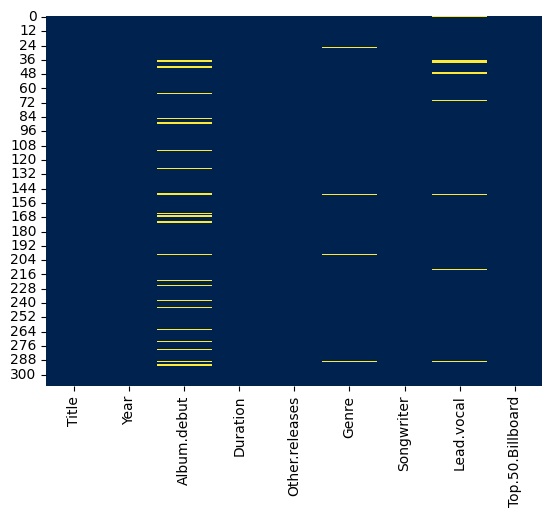

In [4]:
# Display the heatmap (missing values) of the songs dataset 
# (demonstrate using sb.heatmap(songs.isna(), cbar=False, cmap='cividis') vs. 
# sb.heatmap(songs.isna(), cbar=False, cmap='cividis');)
sb.heatmap(songs.isna(), cmap='cividis', cbar=False);

How many missing values are there? (`<pd.df>.isna().sum()` for all columns, `<pd.df>.['<column>'].isna().sum()` for a specific column, `<pd.df>.isna()[['<column1>', 'column2', ...]].sum()` for selected multiple columns; `isnull()` is the same as `isna()`, and `isna()` is used more often).

Try also `<pd.df>.isna()`, `<pd.df>.isna()[['<column1>', 'column2', ...]]`, `type(<pd.df>.isna())`, `type(<pd.df>.isna().sum())`, `type(<pd.df>.isna()[['<column1>', 'column2', ...]].sum())`, `<pd.df>.isna().sum().value_counts()`.

In [6]:
songs.isna().sum()
songs.isna().sum().value_counts()

0     6
22    1
4     1
8     1
Name: count, dtype: int64

How many missing values are there in the columns where there *are* missing values? `<i> = <pd.df>.isna().sum() > 0`, `<pd.df>.isna().sum()[<i>]`. 
Try also `<i>`, `type(<i>)`, `<i>[<i>]`, `<pd.df>.loc[:, <i>]`.

In [13]:
i = songs.isna().sum() > 0
i
i[i]
songs.isna().sum()
songs.isna().sum()[i]
type(songs.isna().sum()[i])

pandas.Series

Leave out rows with `np.NaN` values: `<pd.df>.dropna()`, `<pd.df>.<column>.dropna()`, `<pd.df>['<column>'].dropna()`.

In [19]:
songs.dropna()
songs.isna().sum()[i]
songs['Album.debut'].dropna()
songs.loc[~songs['Album.debut'].isna(), :]

,Title,Year,Album.debut,Duration,Other.releases,Genre,Songwriter,Lead.vocal,Top.50.Billboard
0,12-Bar Original,1965,Anthology 2,174,0,Blues,"Lennon, McCartney, Harrison and Starkey",NaN,-1
1,A Day in the Life,1967,Sgt. Pepper's Lonely Hearts Club Band,335,12,"Psychedelic Rock, Art Rock, Pop/Rock",Lennon and McCartney,Lennon and McCartney,-1
2,A Hard Day's Night,1964,UK: A Hard Day's Night US: 1962-1966,152,35,"Rock, Electronic, Pop/Rock",Lennon,"Lennon, with McCartney",8
3,A Shot of Rhythm and Blues,1963,Live at the BBC,104,0,"R&B, Pop/Rock",Thompson,Lennon,-1
4,A Taste of Honey,1963,UK: Please Please Me US: The Early Beatles,163,29,"Pop/Rock, Jazz, Stage&Screen","Scott, Marlow",McCartney,-1
...,...,...,...,...,...,...,...,...,...
305,You're Going to Lose That Girl,1965,Help!,140,6,"Rock, Pop/Rock",Lennon,Lennon,-1
306,You've Got to Hide Your Love Away,1965,Help!,131,12,FolkPop/Rock,Lennon,Lennon,-1
307,You've Really Got a Hold on Me,1963,UK: With the Beatles US: The Beatles Second Album,182,2,"Soul, Pop/Rock",Robinson,Lennon and Harrison,-1
308,Young Blood,1963,Live at the BBC,116,0,Pop/Rock,"Leiber, Stoller",Harrison,-1


Leave out columns with `np.NaN` values: `<pd.df>.dropna(axis=1)` (or `<pd.df>.dropna(axis='columns')`).

In [20]:
songs.dropna(axis='columns')

,Title,Year,Duration,Other.releases,Songwriter,Top.50.Billboard
0,12-Bar Original,1965,174,0,"Lennon, McCartney, Harrison and Starkey",-1
1,A Day in the Life,1967,335,12,Lennon and McCartney,-1
2,A Hard Day's Night,1964,152,35,Lennon,8
3,A Shot of Rhythm and Blues,1963,104,0,Thompson,-1
4,A Taste of Honey,1963,163,29,"Scott, Marlow",-1
...,...,...,...,...,...,...
305,You're Going to Lose That Girl,1965,140,6,Lennon,-1
306,You've Got to Hide Your Love Away,1965,131,12,Lennon,-1
307,You've Really Got a Hold on Me,1963,182,2,Robinson,-1
308,Young Blood,1963,116,0,"Leiber, Stoller",-1


In [51]:
# Save the modified dataset
songs.to_csv('../data/The Beatles songs dataset, v2.csv', index=False)

##### Value counts
Show value counts for a dataframe: `<pd.df>.value_counts()`, `<pd.df>.value_counts(normalize=True)`.
- `<pd.df>['<column>'].value_counts()` (shows only the rows without NAs (default: dropna=True), check shape)
- `<pd.df>['<column>'].value_counts(normalize=True)` (show proportions, rather than frequencies)


In [24]:
songs.value_counts()
songs['Album.debut'].value_counts()

Album.debut
Live at the BBC                                                    31
The Beatles                                                        30
Anthology 1                                                        21
Abbey Road                                                         17
Sgt. Pepper's Lonely Hearts Club Band                              13
Let It Be                                                          12
UK: Please Please Me US: The Early Beatles                         11
Magical Mystery Tour                                               11
Revolver                                                           11
Rubber Soul                                                        10
UK: With the Beatles US: Meet The Beatles!                          9
Anthology 3                                                         9
UK: A Hard Day's Night US: Something New                            8
UK: Beatles for Sale US: Beatles '65                                8
Help!   

##### Duplicates
The `<pd.df>.duplicated()` method returns a `pd.Series` object with boolean values denoting duplicated rows. The removal of duplicated rows is done by `<pd.df>.drop_duplicates()` (see below).

Find/Show *complete* duplicates (if any): `<pd.df>.duplicated()` (keeps the first occurrence by default, i.e. marks duplicates as `True` except for the first occurrence), `<pd.df>.duplicated(keep='last)` (keeps the last occurrence by default, i.e. marks duplicates as `True` except for the last occurrence), `<pd.df>.duplicated(keep=False)` (marks all occurrences as `True`).

Find duplicates based on a specific column): `<pd.df>.<column>.duplicated()`, `<pd.df>.duplicated(subset=['<column>'])`.

Find duplicates based on multiple specific columns: `<pd.df>.duplicated(subset=['<column 1>', '<column 2>',...])`. 

Drop *complete* duplicates (if any): `<pd.df>.drop_duplicates(inplace=True)`.

Remove rows with duplicates in a certain column (if any), keeping the first row with that value in that column (default): `<pd.df>.drop_duplicates('<column>', inplace=True)`, or keeping the last row with that value in that column: `<pd.df>.drop_duplicates('<column>', keep='last', inplace=True)`.

In [7]:
# Show duplicated songs (complete duplicates)
songs.duplicated().sum()
songs.drop_duplicates()
# songs.duplicated()

,Title,Year,Album.debut,Duration,Other.releases,Genre,Songwriter,Lead.vocal,Top.50.Billboard
0,12-Bar Original,1965,Anthology 2,174,0,Blues,"Lennon, McCartney, Harrison and Starkey",NaN,-1
1,A Day in the Life,1967,Sgt. Pepper's Lonely Hearts Club Band,335,12,"Psychedelic Rock, Art Rock, Pop/Rock",Lennon and McCartney,Lennon and McCartney,-1
2,A Hard Day's Night,1964,UK: A Hard Day's Night US: 1962-1966,152,35,"Rock, Electronic, Pop/Rock",Lennon,"Lennon, with McCartney",8
3,A Shot of Rhythm and Blues,1963,Live at the BBC,104,0,"R&B, Pop/Rock",Thompson,Lennon,-1
4,A Taste of Honey,1963,UK: Please Please Me US: The Early Beatles,163,29,"Pop/Rock, Jazz, Stage&Screen","Scott, Marlow",McCartney,-1
...,...,...,...,...,...,...,...,...,...
305,You're Going to Lose That Girl,1965,Help!,140,6,"Rock, Pop/Rock",Lennon,Lennon,-1
306,You've Got to Hide Your Love Away,1965,Help!,131,12,FolkPop/Rock,Lennon,Lennon,-1
307,You've Really Got a Hold on Me,1963,UK: With the Beatles US: The Beatles Second Album,182,2,"Soul, Pop/Rock",Robinson,Lennon and Harrison,-1
308,Young Blood,1963,Live at the BBC,116,0,Pop/Rock,"Leiber, Stoller",Harrison,-1


In [31]:
# Show duplicates based on the song title (the 'track' column) only
songs.Title.duplicated().sum()

np.int64(1)

In [38]:
# Show the effect of removing duplicates based on the song title (the 'track' column), i.e. without inplace=True
songs.Title.drop_duplicates()
songs.Title.duplicated()
songs.loc[songs.Title.duplicated(), :]
songs.loc[songs.Title == "I'm Talking About You", :]

,Title,Year,Album.debut,Duration,Other.releases,Genre,Songwriter,Lead.vocal,Top.50.Billboard
136,I'm Talking About You,1962,"Live! at the Star-Club in Hamburg, Germany; 1962",150,0,"Rock and Roll, Pop/Rock",Berry,Lennon,-1
137,I'm Talking About You,1963,On Air - Live at the BBC Volume 2,112,0,Pop/Rock,Berry,Lennon,-1


##### Removing the rows with a specific value (specific values) in a certain column
Use: `<pd.df> = <pd.df>[<pd.df>.<column> == <value>, inplace=True)`, `<pd.df> = <pd.df>[<pd.df>['<column>'] == <value>, inplace=True)`, `<pd.df> = <pd.df>[<pd.df>.<column> != <value>, inplace=True)`, `<pd.df> = <pd.df>[<pd.df>['<column>'] != <value>, inplace=True)`, `<pd.df>[<pd.df>.<column>.isin([<value 1>, <value 2>, ...])]`, and the like.

In [48]:
# Remove the songs appearing on live, compilation, and box set albums, using
# <pd.df>[<pd.df>.<column>.isin([<value 1>, <value 2>, ...])]
songs[~songs.Year.isin(list(range(1962, 1971)))]
# list(range(1962, 1971))


,Title,Year,Album.debut,Duration,Other.releases,Genre,Songwriter,Lead.vocal,Top.50.Billboard
0,12-Bar Original,1965,Anthology 2,174,0,Blues,"Lennon, McCartney, Harrison and Starkey",NaN,-1
1,A Day in the Life,1967,Sgt. Pepper's Lonely Hearts Club Band,335,12,"Psychedelic Rock, Art Rock, Pop/Rock",Lennon and McCartney,Lennon and McCartney,-1
2,A Hard Day's Night,1964,UK: A Hard Day's Night US: 1962-1966,152,35,"Rock, Electronic, Pop/Rock",Lennon,"Lennon, with McCartney",8
3,A Shot of Rhythm and Blues,1963,Live at the BBC,104,0,"R&B, Pop/Rock",Thompson,Lennon,-1
4,A Taste of Honey,1963,UK: Please Please Me US: The Early Beatles,163,29,"Pop/Rock, Jazz, Stage&Screen","Scott, Marlow",McCartney,-1
...,...,...,...,...,...,...,...,...,...
305,You're Going to Lose That Girl,1965,Help!,140,6,"Rock, Pop/Rock",Lennon,Lennon,-1
306,You've Got to Hide Your Love Away,1965,Help!,131,12,FolkPop/Rock,Lennon,Lennon,-1
307,You've Really Got a Hold on Me,1963,UK: With the Beatles US: The Beatles Second Album,182,2,"Soul, Pop/Rock",Robinson,Lennon and Harrison,-1
308,Young Blood,1963,Live at the BBC,116,0,Pop/Rock,"Leiber, Stoller",Harrison,-1


In [50]:
# Remove the remaining duplicate: <pd.df>.drop_duplicates('track / Title', keep='first'|'last', inplace=True), or
# <pd.df>.drop_duplicates(subset=['<column1>', '<column2>', ...], keep='first'|'last', inplace=True);
# alternatively, <pd.df>.drop(index=<i>, inplace=True), <pd.df>.drop(index=[<i1>, <i2>, ...], inplace=True)
songs.drop_duplicates(subset=['Title'], keep='last', inplace=True)

In [51]:
# Check for duplicates now; if there ARE duplicates left, examine them and their features manually
songs.Title.duplicated().sum()

np.int64(0)

In [52]:
# Reset index to 0:n: <pd.df>.reset_index(drop=True, inplace=True); drop=True: do not insert index into columns
songs.reset_index(drop=True, inplace=True)

In [53]:
# Save the modified dataset
songs
songs.to_csv('../data/The Beatles songs dataset, v3.csv', index=False)

,Title,Year,Album.debut,Duration,Other.releases,Genre,Songwriter,Lead.vocal,Top.50.Billboard
0,12-Bar Original,1965,Anthology 2,174,0,Blues,"Lennon, McCartney, Harrison and Starkey",NaN,-1
1,A Day in the Life,1967,Sgt. Pepper's Lonely Hearts Club Band,335,12,"Psychedelic Rock, Art Rock, Pop/Rock",Lennon and McCartney,Lennon and McCartney,-1
2,A Hard Day's Night,1964,UK: A Hard Day's Night US: 1962-1966,152,35,"Rock, Electronic, Pop/Rock",Lennon,"Lennon, with McCartney",8
3,A Shot of Rhythm and Blues,1963,Live at the BBC,104,0,"R&B, Pop/Rock",Thompson,Lennon,-1
4,A Taste of Honey,1963,UK: Please Please Me US: The Early Beatles,163,29,"Pop/Rock, Jazz, Stage&Screen","Scott, Marlow",McCartney,-1
...,...,...,...,...,...,...,...,...,...
304,You're Going to Lose That Girl,1965,Help!,140,6,"Rock, Pop/Rock",Lennon,Lennon,-1
305,You've Got to Hide Your Love Away,1965,Help!,131,12,FolkPop/Rock,Lennon,Lennon,-1
306,You've Really Got a Hold on Me,1963,UK: With the Beatles US: The Beatles Second Album,182,2,"Soul, Pop/Rock",Robinson,Lennon and Harrison,-1
307,Young Blood,1963,Live at the BBC,116,0,Pop/Rock,"Leiber, Stoller",Harrison,-1


### Examining individual data items, rows and columns
- `<pd.df>.sample()`
- Simple indexing and fancy indexing: `<pd.df>.iloc[]`, `<pd.df>.loc[]`
- `<pd.df>.index`, `<pd.df>.index[<from>:<to>]`, `<pd.df>.reset_index(drop=True, inplace=True)`
- Indexing using list of values: `<pd.df>.loc[<pd.df>.<column>.isin(<list of values>)]` (select those observations where the value of <column> is in the `<list of values>`)
- Indexing in data stats: `<pd.df>.describe().loc['50%', '<column_name>']` (select the median of `<column_name>` from the `<pd.df>` stats computed by `describe()`)

Read a dataset with missing values.

In [3]:
songs = pd.read_csv('../data/The Beatles songs dataset, v2.csv')
songs.sample(10)

,Title,Year,Album.debut,Duration,Other.releases,Genre,Songwriter,Lead.vocal,Top.50.Billboard
91,"Hello, Goodbye",1967,Magical Mystery Tour,207,14,Pop/Rock,McCartney,McCartney,7
198,One After 909,1969,Let It Be,172,17,"Roots Rock, Pop/Rock",Lennon,"Lennon, with McCartney",-1
292,Woman,1965,NaN,145,0,"Folk Rock, Pop/Rock",McCartney (as Bernard Webb or A. Smith),McCartney,-1
216,Rocky Raccoon,1968,The Beatles,213,9,"Country, Folk Rock, Pop/Rock","McCartney, with Lennon",McCartney,-1
170,Lucille,1963,Live at the BBC,141,0,"Rock and Roll, Pop/Rock","Penniman, Collins",McCartney,-1
294,Yellow Submarine,1966,Revolver,158,24,"Children's Music, Folk, Pop/Rock",McCartney,Starkey,25
215,Rock and Roll Music,1964,UK: Beatles for Sale US: Beatles '65,150,25,"Rock and Roll, Pop/Rock",Berry,Lennon,-1
76,Get Back,1969,Let It Be,194,28,"Blues Rock, Pop/Rock",McCartney,McCartney,4
176,Martha My Dear,1968,The Beatles,148,6,"Music Hall, Pop/Rock",McCartney,McCartney,-1
301,You Like Me Too Much,1965,UK: Help! US: Beatles VI,155,12,Pop/Rock,Harrison,Harrison,-1


Take a sample of the dataset to get a feeling of what's in there.

What are the songs that have *some* missing values? 
Use masking to create the index of such elements; e.g. `<i>`, e.g., `<i> = songs.isna().sum() > 0` and show the type of the result (it's a `pd.Series` object).
Display `<i>.index` and `<i>.values`. 

In [7]:
i = songs.isna().sum() > 0
i
i[i]
i.index
i.values

array([False, False,  True, False, False,  True, False,  True, False])

From the `pd.Series` object `<i>` created in the previous step, select the elements that have the values > 0 (i.e., the names of the columns that have some `NaN` values) - `<i>[<i>]`, `<i>[<i>.values > 0]` (works because `<i>.values` are `True` and `False`, and `True.__int__() = 1`).

Also, from the `<pd.df>` select a subset with only those columns that have *some* `NaN` values - `<pd.df>.loc[:, <i>]`.

In [8]:
i[i]

Album.debut    True
Genre          True
Lead.vocal     True
dtype: bool

How many `NaN`s are there in each column that has `NaN`s? `<pd.df>.isna().sum()[i]`.

In [9]:
songs.isna().sum()[i]

Album.debut    22
Genre           4
Lead.vocal      8
dtype: int64

From a `<pd.df>` select all *rows* that have *some* missing values: `<pd.df>[<pd.df>.isna().any(axis=1)]`, `<pd.df>.loc[<pd.df>.isna().any(axis=1)]`, `<pd.df>.loc[<pd.df>.isna().any(axis=1), :]`.

In [13]:
songs.loc[songs.isna().any(axis=1), :]

,Title,Year,Album.debut,Duration,Other.releases,Genre,Songwriter,Lead.vocal,Top.50.Billboard
0,12-Bar Original,1965,Anthology 2,174,0,Blues,"Lennon, McCartney, Harrison and Starkey",NaN,-1
26,Because I Know You Love Me So,1969,Let It Be... Naked - Fly on the Wall bonus disc,150,0,NaN,"Lennon, McCartney","Lennon, McCartney",-1
37,Catswalk,1962,NaN,150,0,Pop/Rock,McCartney,NaN,-1
38,Cayenne,1960,Anthology 1,144,0,"Instrumental Rock, Pop/Rock",McCartney,NaN,-1
42,Circles,1968,NaN,226,0,"Hindustani Blues, Pop/Rock",Harrison,Harrison,-1
47,Cry for a Shadow,1961,Anthology 1,140,0,"Instrumental Rock, Pop/Rock",Lennon and Harrison,NaN,-1
64,Etcetera,1968,NaN,150,0,Pop/Rock,McCartney,McCartney,-1
70,Flying,1967,Magical Mystery Tour,137,12,"Psychedelic Rock, Instrumental Rock, Space Roc...","Lennon, McCartney, Harrison and Starkey",NaN,-1
85,Goodbye,1969,NaN,150,0,"Children's, Pop/Rock",McCartney,McCartney,-1
89,Heather,1968,NaN,130,0,"Rock, Pop/Rock",McCartney,McCartney,-1


Select rows based on column conditions: `<pd.df>.loc[<pd.df>.<column 1> == <...>]`, `<pd.df>.loc[(<pd.df>.<column 1> == <...>) & (<pd.df>.<column 2> == <...>)]`, etc. Notice the use of `&`, not `and`.

In [14]:
songs.loc[(songs.Year == 1962) & (songs['Lead.vocal'] == 'Lennon'), :]

,Title,Year,Album.debut,Duration,Other.releases,Genre,Songwriter,Lead.vocal,Top.50.Billboard
18,Ask Me Why,1962,UK: Please Please Me US: The Early Beatles,144,24,Pop/Rock,"Lennon, with McCartney",Lennon,-1
90,Hello Little Girl,1962,Anthology 1,150,0,"Merseybeat, Pop/Rock",Lennon,Lennon,-1
103,How Do You Do It?,1962,Anthology 1,119,0,"Merseybeat, Pop/Rock",Murray,Lennon,-1
112,I Lost My Little Girl,1962,NaN,105,0,"Rock, R&B, Pop/Rock",McCartney,Lennon,-1
136,I'm Talking About You,1962,"Live! at the Star-Club in Hamburg, Germany; 1962",150,0,"Rock and Roll, Pop/Rock",Berry,Lennon,-1


What are the rows that have missing values in a specific column of a `<pd.df>`? For example, what are the songs with missing `Album.debut` values?

Using `isna()`, `loc[]`, `iloc[]`, `len()` and `index`.

Calling `loc[]` effectively means *creating a subset* (typically based on a relational or logical expression over one or more columns of the dataset). In other words, `loc[]` creates a *slice* of the dataframe, so the type of the result is `<pd.df>`.

Note that `loc[]` works as `loc[<selected rows>, <selected columns>]`. The indices `<selected rows>` and `<selected columns>` can be created either directly in `loc[]` or beforehand.

If defining the <selected rows> index to be used with `loc[]` subsequently, it is a good practice to define it as a boolean *mask* over a single column, like `<pd.df>['<column>'].isna()`, or as a logical expression in which each chunk is a relational expression over a single column, e.g. `<pd.df>['<column1>'].isna() & <pd.df>['<column2>'] < 23`. The result will be a subset of the original dataframe (i.e., another `<pd.df>`).

Defining the relevant index with a statement like `<pd.df>.loc[<pd.df>['<column>'].isna()].index` is a good starting point when using `iloc[]` subsequently.

If using `iloc[]`, don't forget the `.index` chunk in the statement used to create the index (such as `<pd.df>.loc[<pd.df>['<column>'].isna()].index`). Without it, the result is another `<pd.df>`.

In [35]:
# Define i_iloc, the index to be used with iloc[], starting from <i> = <pd.df>['<column>'].isna();
# iloc[] can be used conveniently here if the relevant index is already defined with <pd.df>.loc[<i>].index, i.e. <pd.df>.loc[<pd.df>['<column>'].isna()].index;
# remember that the second index in iloc[] must be a number too (the relevant column index)
i = songs['Album.debut'].isna()
i[i]
# i_iloc = songs.loc[i].index
i_iloc = i[i].index
i_iloc
# display(songs.iloc[i_iloc, [0, 2]])
songs.iloc[i_iloc, [0, 2, 4]]

# Define i_loc, the index (boolean mask) to be used with loc[], e.g. i_loc = <pd.df>['<column>'].isna()
i_loc = songs['Album.debut'].isna()

# display(songs.loc[i_loc.index, ['track', 'track_composers']])
songs.loc[i_loc, ['Title', 'Year']]

,Title,Year
37,Catswalk,1962
42,Circles,1968
64,Etcetera,1968
85,Goodbye,1969
89,Heather,1968
112,I Lost My Little Girl,1962
127,I'll Keep You Satisfied,1963
148,Jazz Piano Song,1969
149,Jessie's Dream,1967
165,Looking Glass,1962


Replace `NaN` values in `track_composers` with `'unknown'` (`<pd.df>.loc[<i_loc>, '<column>'] = <new value>`, `<pd.df>.iloc[<i_iloc>, <column index>] = <new value>`).

In [36]:
# Make the replacement and display it
songs.loc[i_loc, ['Album.debut']] = 'unknown'
songs.loc[i_loc, ['Title', 'Album.debut']]

,Title,Album.debut
37,Catswalk,unknown
42,Circles,unknown
64,Etcetera,unknown
85,Goodbye,unknown
89,Heather,unknown
112,I Lost My Little Girl,unknown
127,I'll Keep You Satisfied,unknown
148,Jazz Piano Song,unknown
149,Jessie's Dream,unknown
165,Looking Glass,unknown


Double-check the missing values now:

In [38]:
# Use <pd.df>.<column>.isna().sum(), or <pd.df>.isna().sum()['<column>'], or 
# sb.heatmap(<pd.df>.isna(), cmap='...')
songs.isna()['Album.debut'].sum()
# songs.isna()['Album.debut']

0      False
1      False
2      False
3      False
4      False
       ...  
305    False
306    False
307    False
308    False
309    False
Name: Album.debut, Length: 310, dtype: bool

How many songs from the beginning of The Beatles career are there?

In [42]:
# Define the beginning of The Beatles career as a list comprehension
early_years = [y for y in songs.Year if y < 1962]
early_years = list(set(early_years))
early_years
# Display the songs from the early years using a combination of <pd.df>.loc[] and isin()
songs.loc[songs.Year.isin(early_years), :]

,Title,Year,Album.debut,Duration,Other.releases,Genre,Songwriter,Lead.vocal,Top.50.Billboard
7,Ain't She Sweet,1961,Anthology 1,150,9,Pop/Rock,"Yellen, Ager",Lennon,41
38,Cayenne,1960,Anthology 1,144,0,"Instrumental Rock, Pop/Rock",McCartney,NaN,-1
47,Cry for a Shadow,1961,Anthology 1,140,0,"Instrumental Rock, Pop/Rock",Lennon and Harrison,NaN,-1
87,"Hallelujah, I Love Her So",1960,Anthology 1,155,0,"Blues, Jazz, R&B, Pop/Rock",Charles,McCartney,-1
144,In Spite of All the Danger,1958,Anthology 1,164,0,"Skiffle, Blues, Rock and Roll, Pop/Rock",McCartney and Harrison,Lennon,-1
187,My Bonnie,1961,Anthology 1,150,13,"Rock and Roll, Pop/Rock","Traditional, arr. Sheridan",Sheridan,45
252,That'll Be the Day,1958,Anthology 1,136,0,"Rock and Roll, Rockabilly, Pop/Rock","Allison, Holly, Petty",Lennon,-1
289,Winston's Walk,1960,unknown,150,0,NaN,Lennon,NaN,-1
304,You'll Be Mine,1960,Anthology 1,98,0,"R&B, Experimental, Pop/Rock",Lennon and McCartney,McCartney,-1


### Grouping and sorting data
- `<pd.df>['<column>'].unique()`, `<pd.df>['<column>'].nunique()`
- `<pd.df>.<column>.groupby()`, `<pd.df>.groupby('<column>')`, `<pd.df>.groupby('<column>').get_group(<value>)`
- `<pd.df>['<column>'].value_counts()`, `<pd.df>['<column>'].value_counts().sort_index()`, `<pd.df>['<column>'].value_counts().sort_index(inplace=True)`
- `<pd.df>.sort_values(by='<column name>', ascending=False/True)`
- `<pd.df>.groupby('<column>').<another column>.<f()>.sort_values(ascending=False)` (aggregate using function `f()`, e.g. `mean()`)
- `<pd.df>.groupby('<column>').<another column>.agg(['<f1 name>', '<f2 name>', ...])` (aggregate using multiple functions, e.g. `mean()`, `count()`,...)

If `sort_values()` is used after `agg([<'f1 name>', '<f2 name>', ...])` (`agg(['<f1 name>', '<f2 name>', ...]).sort_values(by='<f name>', ascending=False)`), it must be passed one positional argument (`by='<f name>'`) before the optional `ascending=False`.


Read a dataset without missing values.

In [6]:
s1 = pd.read_csv('../data/The Beatles songs dataset, v2, no NAs, left.csv')
s2 = pd.read_csv('../data/The Beatles songs dataset, v2, no NAs, right.csv')
s1.sample(5)
s2.sample(5)
songs = pd.concat([s1, s2], axis=1)
songs
songs.drop('Song title', axis=1, inplace=True)
songs

,Title,Year,Album.debut,Duration,Other.releases,Genre,Songwriter,Lead.vocal,Top.50.Billboard
0,12-Bar Original,1965,Anthology 2,174,0,Blues,"Lennon, McCartney, Harrison and Starkey",NaN,-1
1,A Day in the Life,1967,Sgt. Pepper's Lonely Hearts Club Band,335,12,"Psychedelic Rock, Art Rock, Pop/Rock",Lennon and McCartney,Lennon and McCartney,-1
2,A Hard Day's Night,1964,UK: A Hard Day's Night US: 1962-1966,152,35,"Rock, Electronic, Pop/Rock",Lennon,"Lennon, with McCartney",8
3,A Shot of Rhythm and Blues,1963,Live at the BBC,104,0,"R&B, Pop/Rock",Thompson,Lennon,-1
4,A Taste of Honey,1963,UK: Please Please Me US: The Early Beatles,163,29,"Pop/Rock, Jazz, Stage&Screen","Scott, Marlow",McCartney,-1
...,...,...,...,...,...,...,...,...,...
305,You're Going to Lose That Girl,1965,Help!,140,6,"Rock, Pop/Rock",Lennon,Lennon,-1
306,You've Got to Hide Your Love Away,1965,Help!,131,12,FolkPop/Rock,Lennon,Lennon,-1
307,You've Really Got a Hold on Me,1963,UK: With the Beatles US: The Beatles Second Album,182,2,"Soul, Pop/Rock",Robinson,Lennon and Harrison,-1
308,Young Blood,1963,Live at the BBC,116,0,Pop/Rock,"Leiber, Stoller",Harrison,-1


How many unique values for `Year` are there in the dataset (`<pd.df>['<column>'].unique()`, `<pd.df>.<column>.unique()`; `<pd.df>['<column>'].nunique()`, `<pd.df>.<column>.nunique()`)?

In [8]:
songs.Year.unique()
songs.Year.nunique()

14

Group the songs in the dataset by the year of release (`<pd.df>.groupby('<column>')`). The result can be `songs_by_year`. Display it, show its type, and explore its individual groups and their types (`<pd.df>.groupby('<column>').get_group(<value>)`). 

In [17]:
songs_by_year = songs.groupby('Year')
songs_by_year
songs_by_year.get_group(1965)

,Title,Year,Album.debut,Duration,Other.releases,Genre,Songwriter,Lead.vocal,Top.50.Billboard
0,12-Bar Original,1965,Anthology 2,174,0,Blues,"Lennon, McCartney, Harrison and Starkey",NaN,-1
6,Act Naturally,1965,UK: Help! US: Yesterday and Today,139,14,"Country, Pop/Rock","Russell, Morrison",Starkey,50
16,Another Girl,1965,Help!,124,9,"Country Rock, Pop/Rock",McCartney,McCartney,-1
23,Bad Boy,1965,UK: A Collection of Beatles Oldies US: Beatles VI,150,0,R&B,Williams,Lennon,-1
49,Day Tripper,1965,UK: A Collection of Beatles Oldies US: Yesterd...,170,20,"Rock, Pop/Rock","Lennon, with McCartney",Lennon and McCartney,29
54,"Dizzy, Miss Lizzy",1965,UK: Help! US: Beatles VI,145,18,"Rock and Roll, Pop/Rock",Williams,Lennon,-1
61,Drive My Car,1965,UK: Rubber Soul US: Yesterday and Today,148,17,"Rock, R&B, Pop/Rock","McCartney, with Lennon","McCartney, with Lennon",-1
78,Girl,1965,Rubber Soul,153,17,"Folk, Pop/Rock",Lennon,Lennon,-1
92,Help!,1965,Help!,138,34,"Folk Rock, Pop/Rock","Lennon, with McCartney",Lennon,14
114,I Need You,1965,Help!,148,11,Pop/Rock,Harrison,Harrison,-1


How many songs are there in the dataset for each `Year` (`<pd.df>['<column>'].value_counts()`, `<pd.df>['<column>'].value_counts()[<year>]`, `<pd.df>['<column>'].value_counts().sort_index()`)?

Note that `value_counts()` returns a `pd.Series` object, with the index equal to `<pd.df>['<column>'].unique()` values.

In [16]:
songs.Year.value_counts()
# type(songs.Year.value_counts())
songs.Year.value_counts().sort_values(ascending=False)
songs.Year.value_counts().sort_index(ascending=False)

Year
1980     1
1977     1
1970     1
1969    43
1968    45
1967    27
1966    19
1965    37
1964    41
1963    66
1962    20
1961     3
1960     4
1958     2
Name: count, dtype: int64

Sort the songs from the dataset by the year of release (`<pd.df>.sort_values(by='<column name>', ascending=False/True)`).
(It is also possible to use `inplace=True` in `sort_values()`, but it will change the order of songs in the dataset from that point on.)

In [18]:
songs.sort_values(by='Year', ascending=False)

,Title,Year,Album.debut,Duration,Other.releases,Genre,Songwriter,Lead.vocal,Top.50.Billboard
210,Real Love,1980,Anthology 2,236,2,"Rock, Pop/Rock","Lennon, with McCartney, Harrison, Starkey",Lennon,47
73,Free as a Bird,1977,Anthology 1,266,0,"Rock, Pop/Rock","Lennon, with McCartney, Harrison and Starkey","Lennon, McCartney and Harrison",39
113,I Me Mine,1970,Let It Be,145,10,"Folk blues, Hard Rock, Pop/Rock",Harrison,Harrison,-1
44,Come and Get It,1969,Anthology 3,142,0,"Power Pop, Pop/Rock",McCartney,McCartney,-1
279,Watching Rainbows,1969,NaN,248,0,"Rock, Pop/Rock","Lennon, with McCartney",Lennon,-1
...,...,...,...,...,...,...,...,...,...
304,You'll Be Mine,1960,Anthology 1,98,0,"R&B, Experimental, Pop/Rock",Lennon and McCartney,McCartney,-1
289,Winston's Walk,1960,NaN,150,0,NaN,Lennon,NaN,-1
87,"Hallelujah, I Love Her So",1960,Anthology 1,155,0,"Blues, Jazz, R&B, Pop/Rock",Charles,McCartney,-1
144,In Spite of All the Danger,1958,Anthology 1,164,0,"Skiffle, Blues, Rock and Roll, Pop/Rock",McCartney and Harrison,Lennon,-1


Group the songs in the dataset by the year of release and display `mean` and/or `max` duration of the songs in each year, as well as the number (`count`) of songs in each year (`<pd.df>.groupby('<column>').<another column>.<f()>.sort_values(ascending=False)` (aggregate using function `f()`, e.g. `mean()`), `<pd.df>.groupby('<column>').<another column>.agg(['f1 name>', '<f2 name>', ...])` (aggregate using multiple functions, e.g. `mean()`, `count()`, `max()`,...)).
If `sort_values()` is used after `agg([<'f1 name>', '<f2 name>', ...])` (`agg(['<f1 name>', '<f2 name>', ...]).sort_values(by='<f name>', ascending=False)`), it must be passed one positional argument (`by='<f name>'`) before the optional `ascending=False`.

In [20]:
# Make the groupings and aggregations

# <pd.df>.groupby('<column>').<another column>.<f()>.sort_values(ascending=False)
songs_by_year.Duration.mean().sort_values(ascending=False)
# <pd.df>.groupby('<column>').<another column>.agg(['<f1 name>', '<f2 name>', ...]).sort_values(by='<f name>', ascending=False)
songs_by_year.Duration.agg(['count', 'mean', 'max']).sort_values(by='count', ascending=False)

,count,mean,max
Year,,,
1963,66,136.045455,182
1968,45,194.511111,502
1969,43,169.255814,467
1964,41,144.048780,183
1965,37,149.189189,202
1967,27,196.666667,388
1962,20,140.900000,156
1966,19,157.473684,245
1960,4,136.750000,155


## Data visualization
Plot some scatterplots, line plots, bar graphs, histograms, scatterplots, box plots, violins, heatmaps,...
[Example](https://www.analyticsvidhya.com/blog/2021/08/how-to-perform-exploratory-data-analysis-a-guide-for-beginners/)

[Matplotlib examples](https://matplotlib.org/stable/gallery/index.html)

[Seaborn examples](https://seaborn.pydata.org/examples/index.html) (see also [The Python Graph Gallery](https://www.python-graph-gallery.com/); it has a very neat user interface!)

[Anatomy of a Matplotlib diagram 1](https://aosabook.org/static/matplotlib/artists_tree.png)<br>
[Anatomy of a Matplotlib diagram 2](https://matplotlib.org/stable/_images/sphx_glr_anatomy_001.png)

<u>**Note that it is also possible to**</u> <u>**[plot lines, bargraphs,... with Pandas only](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.plot.line.html)**</u> (although in such cases Pandas interacts with Matplotlib under the hood).

<b>IMPORTANT: Matplotlib terminology, Figure vs. Axes</b><br>
A `Figure` object in Matplotlib is the outermost container for a Matplotlib graphic, which can contain multiple `Axes` objects. One source of confusion is the name: an `Axes` actually translates into what we think of as an individual plot or graph (rather than the plural of "axis", as we might expect).

##### Missing values

Read the dataset.

`pd.read_csv()` returns a `pd.DataFrame` object.

As for specifying the path of the dataset properly, see [this](https://stackoverflow.com/questions/35384358/how-to-open-my-files-in-data-folder-with-pandas-using-relative-path) (more specifically, **both** [this](https://stackoverflow.com/a/35384414/1899061) and [this](https://stackoverflow.com/a/43600253/1899061)).

In [35]:
# Get the songs as a pd.DataFrame object from '../data/The Beatles songs dataset, 285x45, v17.csv',
# or from '../data/The Beatles songs dataset, 285x45, v17.csv', or '../../data/The Beatles songs dataset, 285x45, v17.csv', or ...,
# depending on where the csv file is located
songs = pd.read_csv('../data/The Beatles songs dataset, 285x45, v17.csv')
songs

,URI,Title,Year,Album,Popularity,Duration,Key,Mode,Tempo,Time_signature,...,Weeks at No1 in UK (The Guardian),Highest position (Billboard),Weeks at No1 (Billboard),Top 50 (Billboard),Top 50 (Ultimate classic rock),Top 50 (Rolling Stone),Top 50 (NME),Top 50 (Top50songs.org),"Top 50 (USA today, 2017)","Top 50 (Vulture, by Bill Wyman)"
0,spotify:track:2FDEHIMkjxFLzj688M2I3h,(You're So Square) Baby I Don't Care - Studio Jam,1968,The Beatles,29,43,9,1,112.173,4,...,0,0,0,0,0,0,0,0,0,0
1,spotify:track:2HvTGx5fzFGpHSyRNvXd9T,12-bar Original,1965,Anthology 2,31,175,9,1,122.678,4,...,0,0,0,0,0,0,0,0,0,0
2,spotify:track:0hKRSZhUGEhKU6aNSPBACZ,A Day in the Life,1967,Sgt. Pepper's Lonely Hearts Club Band,65,335,4,0,163.219,4,...,0,0,0,0,50,50,49,33,50,50
3,spotify:track:5J2CHimS7dWYMImCHkEFaJ,A Hard Day's Night,1964,A Hard Day's Night,71,152,0,1,138.514,4,...,3,1,2,43,33,40,32,32,36,10
4,spotify:track:5RuE7nwp4TWsRvLXG7Yjy1,A Shot of Rhythm and Blues,1963,Live at the BBC,35,136,2,1,128.919,4,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
280,spotify:track:70HNt0eoBVqr4ss68U8x3B,You're Going to Lose That Girl,1965,Help!,57,140,4,1,131.975,4,...,0,0,0,0,0,24,0,0,0,0
281,spotify:track:4F1AgKpuFRMLEgtPETVwZk,You've Got to Hide Your Love Away,1965,Help!,73,131,7,1,184.267,3,...,0,0,0,0,9,20,2,0,14,5
282,spotify:track:7rgUYidQh5tH0YlXCoKaYJ,You've Really Got a Hold on Me,1963,With the Beatles,54,182,9,1,77.643,4,...,0,0,0,0,0,0,0,0,0,0
283,spotify:track:3FuRBetiFz4ijeLdGCxQ5Y,Young Blood,1963,Live at the BBC,29,116,2,1,68.111,4,...,0,0,0,0,0,0,0,0,0,0


Check for missing values (use, e.g., `sb.heatmap(<pd.df>.isna(), cbar=False, cmap='viridis')`).

In [36]:
songs.isna().sum().sum()

np.int64(0)

Briefly analyze the rows with `NaN`s. To select all such rows, use `any()` (`<pd.df>.loc[<pd.df>.isna().any(axis=1), ['<column 1>', '<column 2>', ...]`). To select the rows where there are no `NaN`s at all, use `<pd.df>.loc[<pd.df>.notna().all(axis=1), ['<column 1>', '<column 2>', ...]`.

In [37]:
songs.loc[songs.isna().any(axis=1), :]
songs.loc[songs.notna().any(axis=1), :]

,URI,Title,Year,Album,Popularity,Duration,Key,Mode,Tempo,Time_signature,...,Weeks at No1 in UK (The Guardian),Highest position (Billboard),Weeks at No1 (Billboard),Top 50 (Billboard),Top 50 (Ultimate classic rock),Top 50 (Rolling Stone),Top 50 (NME),Top 50 (Top50songs.org),"Top 50 (USA today, 2017)","Top 50 (Vulture, by Bill Wyman)"
0,spotify:track:2FDEHIMkjxFLzj688M2I3h,(You're So Square) Baby I Don't Care - Studio Jam,1968,The Beatles,29,43,9,1,112.173,4,...,0,0,0,0,0,0,0,0,0,0
1,spotify:track:2HvTGx5fzFGpHSyRNvXd9T,12-bar Original,1965,Anthology 2,31,175,9,1,122.678,4,...,0,0,0,0,0,0,0,0,0,0
2,spotify:track:0hKRSZhUGEhKU6aNSPBACZ,A Day in the Life,1967,Sgt. Pepper's Lonely Hearts Club Band,65,335,4,0,163.219,4,...,0,0,0,0,50,50,49,33,50,50
3,spotify:track:5J2CHimS7dWYMImCHkEFaJ,A Hard Day's Night,1964,A Hard Day's Night,71,152,0,1,138.514,4,...,3,1,2,43,33,40,32,32,36,10
4,spotify:track:5RuE7nwp4TWsRvLXG7Yjy1,A Shot of Rhythm and Blues,1963,Live at the BBC,35,136,2,1,128.919,4,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
280,spotify:track:70HNt0eoBVqr4ss68U8x3B,You're Going to Lose That Girl,1965,Help!,57,140,4,1,131.975,4,...,0,0,0,0,0,24,0,0,0,0
281,spotify:track:4F1AgKpuFRMLEgtPETVwZk,You've Got to Hide Your Love Away,1965,Help!,73,131,7,1,184.267,3,...,0,0,0,0,9,20,2,0,14,5
282,spotify:track:7rgUYidQh5tH0YlXCoKaYJ,You've Really Got a Hold on Me,1963,With the Beatles,54,182,9,1,77.643,4,...,0,0,0,0,0,0,0,0,0,0
283,spotify:track:3FuRBetiFz4ijeLdGCxQ5Y,Young Blood,1963,Live at the BBC,29,116,2,1,68.111,4,...,0,0,0,0,0,0,0,0,0,0


If it is difficult to spot any regular pattern, get rid of `NaN`s in the simplest way possible (`<pd.df>.dropna(inplace=True)`). Make sure that the modified dataset is `NaN`-free (`<pd.df>.isna().sum()`).

In [40]:
songs.isna().sum().sum()

np.int64(0)

Save the reduced dataset as `The Beatles songs, visualization.csv`, the starting one to make visualizations.

In [38]:
# Save the modified dataset
songs.to_csv('../data/The Beatles songs dataset, visualization.csv')

##### Scatterplot

Read the modified dataset (if necessary).

`pd.read_csv()` returns a `pd.DataFrame` object.

As for specifying the path of the dataset properly, see [this](https://stackoverflow.com/questions/35384358/how-to-open-my-files-in-data-folder-with-pandas-using-relative-path) (more specifically, **both** [this](https://stackoverflow.com/a/35384414/1899061) and [this](https://stackoverflow.com/a/43600253/1899061)).

In [67]:
songs = pd.read_csv('../data/The Beatles songs dataset, visualization.csv')

Scatterplot the relationship between `Duration` and `Danceability`.

If the format of `Duration` is `str`, change it to `int` - check the type of `Duration` with `songs.dtypes`, and then use `songs['Duration'] = songs['Duration'].astype('int')` if necessary.

In [68]:
songs.dtypes
# songs['Duration'] = songs['Duration'].astype('int')
# songs.dtypes

Unnamed: 0                               int64
URI                                        str
Title                                      str
Year                                     int64
Album                                      str
Popularity                               int64
Duration                                 int64
Key                                      int64
Mode                                     int64
Tempo                                  float64
Time_signature                           int64
Valence                                float64
Danceability                           float64
Energy                                 float64
Loudness                               float64
Acousticness                           float64
Instrumentalness                       float64
Liveness                               float64
Speechiness                            float64
Album debut                                str
Other releases                           int64
Single A side

Save the modified dataset as `The Beatles songs dataset, visualization.csv` or `The Beatles songs dataset, visualization, duration int.csv`.

In [29]:
# Save the modified dataset
songs.to_csv('../data/The Beatles songs dataset, visualization.csv', index=False)

To set the ranges of values on x-axis and y-axis (`Duration`, `Danceability`), check the min and max values or run `describe()`. Even better, run `songs.describe().loc[['min', 'max'], ['Duration', 'Danceability']]`, since `describe()` creates a `<pd.df>` object.

In [69]:
songs.describe()
songs.describe().loc[['min', 'max'], ['Duration', 'Danceability']]

,Duration,Danceability
min,23.0,0.146
max,502.0,0.880


###### 1. Plotting using Matplotlib

[Matplotlib scatterplot example](https://matplotlib.org/stable/gallery/shapes_and_collections/scatter.html)<br>
[Excellent tutorial on matplotlib](https://realpython.com/python-matplotlib-guide/)

Simple version:<br>
`ax = plt.axes()`<br>
`ax.set(xlim=(<from>, <to>), ylim=(<from>, <to>), xlabel='<xlabel>', ylabel='<ylabel>', title='<title>')`<br>
`ax.scatter(<pd.df>['<X>'], <pd.df>['<Y>'], marker='<marker type>', c='<fill color>', edgecolors='<edgecolor>', s=<marker size>)`; <br>

The `<pd.df>['<X>']` and `<pd.df>['<Y>']` arguments can be also specified as `<pd.df>.<X>` and `<pd.df>.<Y>` if `<X>` and `<Y>` are single words.
The color parameter (`c`) is optional; if present, it should be a scalar or a sequence of length consistent with the lengths of `<X>` and `<Y>` (`(<X>, <Y>)` points). The `marker` parameter is optional as well. Both `c` and `marker` have defaults. For other values of `c` and `marker`, see [this](https://matplotlib.org/stable/gallery/color/named_colors.html#css-colors) and [this](https://matplotlib.org/stable/api/_as_gen/matplotlib.markers.MarkerStyle.html#matplotlib.markers.MarkerStyle.markers), respectively. A good value for `s` is 30-40 for 200-300 markers on the plot.

Alternatively:<br>
`ax.plot(<pd.df>['<X>'], <pd.df>['<Y>'], marker='<marker type>', color='<color>', linestyle='');`<br>

The `linestyle=''` parameter is essential for plotting the dots only - omitting it means that the connecting lines are plotted as well.<br><br>

Elaborated version, using plt.subplots():

Get the Figure and the Axes objects

`fig, ax = plt.subplots(nrows=1, ncols=1, layout='constrained', facecolor='color', figsize=(<x_size>, <y_size>))`

Plot the data on the Axes

`ax.scatter(x=<x>, y=<y>, color='<color>', linewidth=<linewidth>, edgecolors='<edgecolors>', marker='<marker type>', s=<dot/point size>, alpha=<transparency>)`

Set the Axes title, background color (face color), labels (incl. font sizes) and limits

`ax.set_title('<title>', fontsize=12, loc='left')`<br>
`ax.set_facecolor('<color>')`<br>
`ax.set_xlabel('<x_label>', fontsize=8)`<br>
`ax.set_ylabel('<y_label>', fontsize=8)`<br>
`ax.set_xlim(<m>, <n>)`<br>
`ax.set_ylim(<p>, <q>)`<br>

Set the tick parameters<br>

`ax.ticklabel_format(useOffset=False)`<br>
`ax.tick_params(axis='x', labelsize=6)`<br>
`ax.tick_params(axis='y', labelsize=6)`<br>

Display the plot<br>

`plt.show()`<br><br>

In `fig, ax = plt.subplots(nrows=1, ncols=1, layout='constrained', facecolor='color', figsize=(<x_size>, <y_size>))`, using `layout='constrained'` is recommended to avoid overlapping of figure elements when changing the figure size. For a good figure size, use `figsize=(3.5, 2)` or similar.

To prevent numbers displayed in scientific notation (exponential) on axes ticks, make sure to use `ax.ticklabel_format(useOffset=False)`.

Experiment with different font sizes for labels, title and ticks.

The `color` parameter can be abbreviated as `c` and is optional; if present, it should be a scalar or a sequence of length consistent with the lengths of `<X>` and `<Y>` (`(<X>, <Y>)` points). The `marker` parameter is optional as well. Both `color` and `marker` have defaults. For other values of `color` and `marker`, see [this](https://matplotlib.org/stable/gallery/color/named_colors.html#css-colors) and [this](https://matplotlib.org/stable/api/_as_gen/matplotlib.markers.MarkerStyle.html#matplotlib.markers.MarkerStyle.markers), respectively. A good value for the dot/point size parameter `s` is 30-40 for 200-300 markers on the plot.

Examples of some parameters in `ax.scatter()`: `color='steelblue'`, `linewidth=1` (the thickness of the dots/points rim), `alpha=0.8` (alpha: transparency (0-1)).

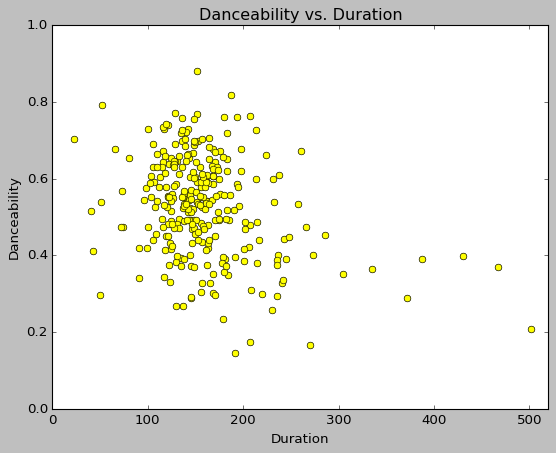

In [70]:
# Simple version
ax = plt.axes()
ax.set(xlim=(0, 520), ylim=(0, 1), xlabel='Duration', ylabel='Danceability', title='Danceability vs. Duration')
ax.scatter(songs['Duration'], songs['Danceability'], marker='o', c='yellow', edgecolors='grey', s=30);

# Alternatively
ax.plot(songs['Duration'], songs['Danceability'], marker='o', color='yellow', linestyle='');


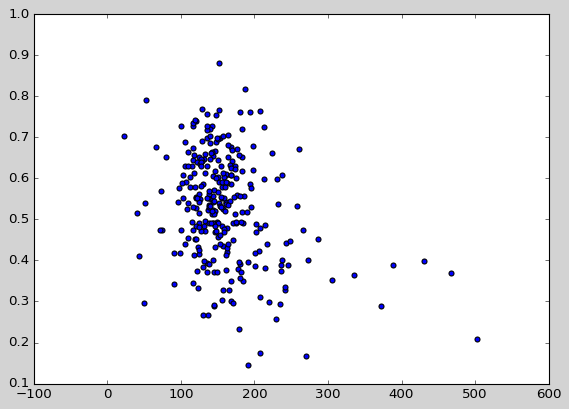

In [71]:
# Elaborated version, using plt.subplots()

# Get the Figure and the Axes objects

fig, ax = plt.subplots(nrows=1, ncols=1, layout='constrained', facecolor='lightgrey', figsize=(7, 5))

# Plot the data on the Axes

# ax.scatter(x=songs.Duration, y=songs.Danceability, color='yellow', linewidth=1, edgecolors='grey', marker='o',
#            s=30, alpha=0.8)

ax.scatter(x=songs.Duration, y=songs.Danceability, )

# # Set the Axes title, background color (face color), labels (incl. font sizes) and limits
#
# ax.set_title('Danceability vs. Duration', fontsize=16, loc='left')
# ax.set_facecolor('beige')
# ax.set_xlabel('Duration', fontsize=13)
# ax.set_ylabel('Danceability', fontsize=13)
# ax.set_xlim(0, 520)
# ax.set_ylim(0, 1)
#
# # Set the tick parameters
#
# ax.ticklabel_format(useOffset=False)
# ax.tick_params(axis='x', labelsize=10)
# ax.tick_params(axis='y', labelsize=10)
#
# # Display the plot

plt.show()

###### 2. A brief analysis of the plot: What are the shortest/longest songs and their durations?

In [72]:
# display(<pd.df>['column'] <= <value>)                                    # Boolean mask
# display(type(<pd.df>['column'] <= <value>))                              # pd.Series
# display(<pd.df>[<pd.df>['column'] <= <value>]['column to to display'])   # select one column
# display(<pd.df>[<pd.df>['column'] <= <value>]['column 1  to to display', 'column 2 to display',...])   # select multiple columns

# Try this also with .loc[], as well as with .iloc[], with an explicitly set index and with .index
songs.loc[songs.Duration <= 100, ['Title', 'Duration']]
songs.loc[songs.Duration >=400, ['Title', 'Duration']]
songs.loc[songs.Danceability >=0.77, ['Title', 'Duration']]

,Title,Duration
68,For You Blue,152
77,Good Day Sunshine,129
179,"Ob-la-di, Ob-la-da",187
265,Wild Honey Pie,52


##### Line plot

Read the modified dataset (if necessary).

`pd.read_csv()` returns a `pd.DataFrame` object.

As for specifying the path of the dataset properly, see [this](https://stackoverflow.com/questions/35384358/how-to-open-my-files-in-data-folder-with-pandas-using-relative-path) (more specifically, **both** [this](https://stackoverflow.com/a/35384414/1899061) and [this](https://stackoverflow.com/a/43600253/1899061)).

In [2]:
songs = pd.read_csv('../data/The Beatles songs dataset, visualization.csv')
songs

,URI,Title,Year,Album,Popularity,Duration,Key,Mode,Tempo,Time_signature,...,Weeks at No1 in UK (The Guardian),Highest position (Billboard),Weeks at No1 (Billboard),Top 50 (Billboard),Top 50 (Ultimate classic rock),Top 50 (Rolling Stone),Top 50 (NME),Top 50 (Top50songs.org),"Top 50 (USA today, 2017)","Top 50 (Vulture, by Bill Wyman)"
0,spotify:track:2FDEHIMkjxFLzj688M2I3h,(You're So Square) Baby I Don't Care - Studio Jam,1968,The Beatles,29,43,9,1,112.173,4,...,0,0,0,0,0,0,0,0,0,0
1,spotify:track:2HvTGx5fzFGpHSyRNvXd9T,12-bar Original,1965,Anthology 2,31,175,9,1,122.678,4,...,0,0,0,0,0,0,0,0,0,0
2,spotify:track:0hKRSZhUGEhKU6aNSPBACZ,A Day in the Life,1967,Sgt. Pepper's Lonely Hearts Club Band,65,335,4,0,163.219,4,...,0,0,0,0,50,50,49,33,50,50
3,spotify:track:5J2CHimS7dWYMImCHkEFaJ,A Hard Day's Night,1964,A Hard Day's Night,71,152,0,1,138.514,4,...,3,1,2,43,33,40,32,32,36,10
4,spotify:track:5RuE7nwp4TWsRvLXG7Yjy1,A Shot of Rhythm and Blues,1963,Live at the BBC,35,136,2,1,128.919,4,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
280,spotify:track:70HNt0eoBVqr4ss68U8x3B,You're Going to Lose That Girl,1965,Help!,57,140,4,1,131.975,4,...,0,0,0,0,0,24,0,0,0,0
281,spotify:track:4F1AgKpuFRMLEgtPETVwZk,You've Got to Hide Your Love Away,1965,Help!,73,131,7,1,184.267,3,...,0,0,0,0,9,20,2,0,14,5
282,spotify:track:7rgUYidQh5tH0YlXCoKaYJ,You've Really Got a Hold on Me,1963,With the Beatles,54,182,9,1,77.643,4,...,0,0,0,0,0,0,0,0,0,0
283,spotify:track:3FuRBetiFz4ijeLdGCxQ5Y,Young Blood,1963,Live at the BBC,29,116,2,1,68.111,4,...,0,0,0,0,0,0,0,0,0,0


How many songs from each `Year` are there?

In [4]:
# Use <pd.df>['<column>'].value_counts(), <pd.df>['<column>'].value_counts()[<specific value> in <column>]
years = songs.Year.value_counts()
years

Year
1963    62
1968    46
1964    38
1969    37
1965    36
1967    25
1966    19
1962    10
1961     3
1960     3
1958     2
1995     1
1970     1
2023     1
1996     1
Name: count, dtype: int64

Sort this result by index: `pd.Series.sort_index()` (there is also `pd.DataFrame.sort_index()`).

In [5]:
# Define val_counts_sorted_by_index
years = years.sort_index()
years.index

Index([1958, 1960, 1961, 1962, 1963, 1964, 1965, 1966, 1967, 1968, 1969, 1970,
       1995, 1996, 2023],
      dtype='int64', name='Year')

Preparation for plotting (`counts` on y-axis, `Year` on x-axis): get the `np.ndarray` version of `val_counts_sorted_by_index`, as well as of its index.

One way of doing it is to use `np.array()` over `val_counts_sorted_by_index.index` and `val_counts_sorted_by_index.values`. However, the same effect is achieved using only `val_counts_sorted_by_index.index` and `val_counts_sorted_by_index.values` (their type is `np.ndarray`).

In [6]:
counts = years.values
counts
years = years.index
years

Index([1958, 1960, 1961, 1962, 1963, 1964, 1965, 1966, 1967, 1968, 1969, 1970,
       1995, 1996, 2023],
      dtype='int64', name='Year')

And now plot it.

###### 1. Plotting using Matplotlib

[Matplotlib line plot example](https://matplotlib.org/stable/gallery/lines_bars_and_markers/simple_plot.html)<br>
[Excellent tutorial on matplotlib](https://realpython.com/python-matplotlib-guide/)
<br>
`ax = plt.axes()`<br>
`ax.set(xlim=(<lower limit>, <upper limit>), ylim=(<lower limit>, <upper limit>), xlabel='...', ylabel='...', title='...')`<br>
`ax.ticklabel_format(useOffset=False)`<br>
`ax.plot(<x>, <y>, color='...', marker='<marker type>', linewidth=<number>, alpha=<number>)`<br>

To prevent numbers displayed in scientific notation (exponential) on axes ticks, make sure to use `ax.ticklabel_format(useOffset=False)`.

Do not use `x=<x>, y=<y>` in `ax.plot()`, it generates an error. Use just `<x>, <y>`. For the other parameters, the keywords are necessary.

Examples of parameters in `ax.plot()`: `color='steelblue'`, `linewidth=3`, `alpha=0.8` (alpha: transparency (0-1)).

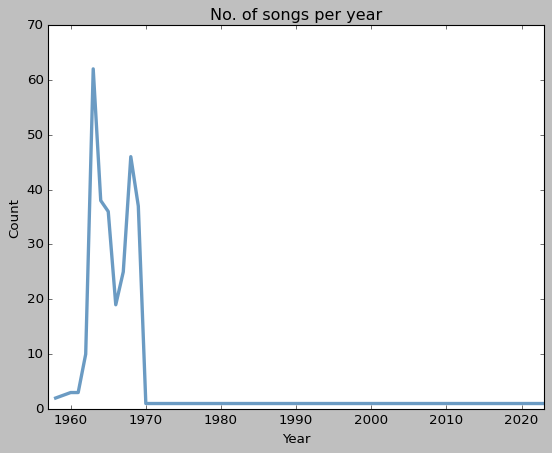

In [8]:
# Simple version
# fig, ax = plt.subplots()
ax = plt.axes()
ax.set(xlim=(1957, 2023), ylim=(0, 70), xlabel='Year', ylabel='Count', title='No. of songs per year')
ax.ticklabel_format(useOffset=False, style='plain')
ax.plot(years, counts, color='steelblue', linewidth=3, alpha=0.8);

<em>Elaborated version 1, without `plt.subplots()`</em><br><br>

Set the Figure object parameters<br>

`plt.figure(layout='constrained', facecolor='<color>', figsize=(<x_size>, <y_size>))`<br>

Get the Axes object<br>

`ax = plt.axes()`<br>

Set the Axes object parameters<br>

`ax.set_facecolor('<color>')`<br>
`ax.set_title('<title>', fontsize=12, loc='left')`<br>
`ax.set_xlabel('<x_label>', fontsize=8)`<br>
`ax.set_ylabel('<y_label>', fontsize=8)`<br>

Without `plt.subplots()`, `xlim` and `ylim` have to be set using `ax.set()`<br>

`ax.set(xlim=(<m>, <n>), ylim=(<p>, <q>))`<br>

Set the tick parameters<br>

`ax.ticklabel_format(useOffset=False)`<br>
`ax.tick_params(axis='x', labelsize=6)`<br>
`ax.tick_params(axis='y', labelsize=6)`<br>

Display the plot using `ax.plot()`<br>

`ax.plot(<x>, <y>, color='<color>', linewidth=<linewidth>, alpha=<transparency>);`<br><br>

In `plt.figure(layout='constrained', facecolor='<color>', figsize=(<x_size>, <y_size>))`, using `layout='constrained'` is recommended to avoid overlapping of figure elements when changing the figure size. For a good figure size, use `figsize=(3.5, 2)` or similar.

It is also possible to set the Axes object background color using `plt.axes(facecolor='<color>')` instead of `ax.set_facecolor('<color>')`.

To prevent numbers displayed in scientific notation (exponential) on axes ticks, make sure to use `ax.ticklabel_format(useOffset=False)`.

Experiment with different font sizes for labels, title and ticks.

**Do not use `x=<x>, y=<y>` in `ax.plot()`, it generates an error. Use just `<x>, <y>`. For the other parameters, the keywords are necessary.**

Examples of parameters in `ax.plot()`: `color='steelblue'`, `linewidth=3`, `alpha=0.8` (alpha: transparency (0-1)).

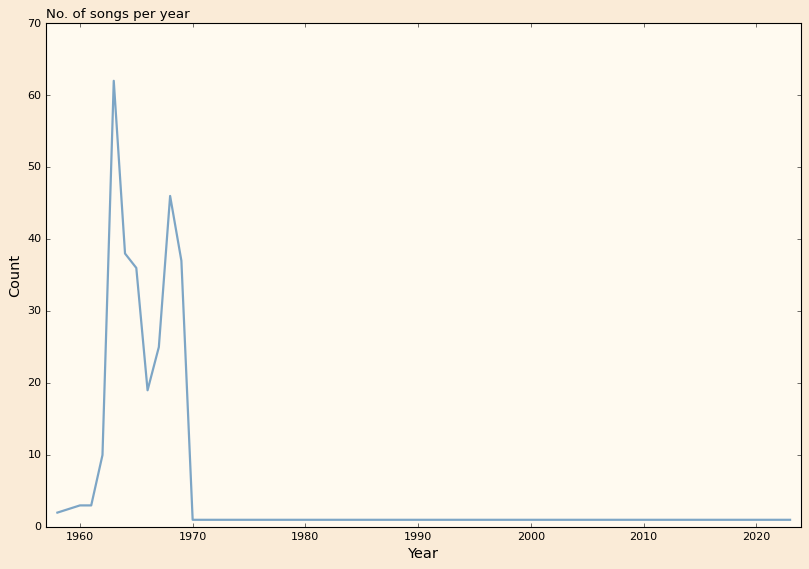

In [9]:
# Elaborated version 1, without plt.subplots()

# Set the Figure object parameters

plt.figure(layout='constrained', facecolor='antiquewhite', figsize=(10, 7))

# Get the Axes object

ax = plt.axes()

# Set the Axes object parameters

ax.set_facecolor('floralwhite')
ax.set_title('No. of songs per year', fontsize=12, loc='left')
ax.set_xlabel('Year', fontsize=13)
ax.set_ylabel('Count', fontsize=13)

# Without `plt.subplots()`, `xlim` and `ylim` have to be set using `ax.set()

ax.set(xlim=(1957, 2024), ylim=(0, 70))

# Set the tick parameters

ax.ticklabel_format(useOffset=False)
ax.tick_params(axis='x', labelsize=10)
ax.tick_params(axis='y', labelsize=10)

# Display the plot using `ax.plot()`

ax.plot(years, counts, color='steelblue', linewidth=2, alpha=0.7);

<em>Elaborated version 2, using `plt.subplots()`</em><br><br>

Get the Figure and the Axes objects

`fig, ax = plt.subplots(nrows=1, ncols=1, layout='constrained', facecolor='color', figsize=(<x_size>, <y_size>))`

Plot the data on the Axes

`ax.plot(<x>, <y>, color='<color>', linewidth=<linewidth>, alpha=<transparency>)`

Set the Axes title, background color (face color), labels (incl. font sizes) and limits

`ax.set_title('<title>', fontsize=12, loc='left')`<br>
`ax.set_facecolor('<color>')`<br>
`ax.set_xlabel('<x_label>', fontsize=8)`<br>
`ax.set_ylabel('<y_label>', fontsize=8)`<br>
`ax.set_xlim(<m>, <n>)`<br>
`ax.set_ylim(<p>, <q>)`<br>

Set the tick parameters<br>

`ax.ticklabel_format(useOffset=False)`<br>
`ax.tick_params(axis='x', labelsize=6)`<br>
`ax.tick_params(axis='y', labelsize=6)`<br>

Display the plot<br>

`plt.show()`<br><br>

In `fig, ax = plt.subplots(nrows=1, ncols=1, layout='constrained', facecolor='color', figsize=(<x_size>, <y_size>))`, using `layout='constrained'` is recommended to avoid overlapping of figure elements when changing the figure size. For a good figure size, use `figsize=(3.5, 2)` or similar.

To prevent numbers displayed in scientific notation (exponential) on axes ticks, make sure to use `ax.ticklabel_format(useOffset=False)`.

Experiment with different font sizes for labels, title and ticks.

**Do not use `x=<x>, y=<y>` in `ax.plot()`, it generates an error. Use just `<x>, <y>`. For the other parameters, the keywords are necessary.**

Examples of parameters in `ax.plot()`: `color='steelblue'`, `linewidth=3`, `alpha=0.8` (alpha: transparency (0-1)).

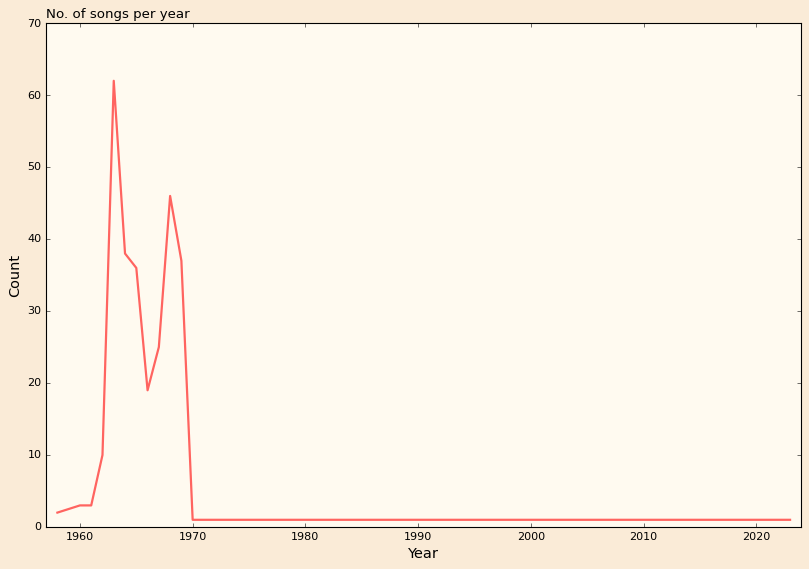

In [10]:
# Elaborated version 2, using plt.subplots()

# Get the Figure and the Axes objects

fig, ax = plt.subplots(nrows=1, ncols=1, layout='constrained', facecolor='antiquewhite', figsize=(10, 7))

# Plot the data on the Axes

ax.plot(years, counts, color='red', linewidth=2, alpha=0.6)

# Set the Axes title, background color (face color), labels (incl. font sizes) and limits

ax.set_facecolor('floralwhite')
ax.set_title('No. of songs per year', fontsize=12, loc='left')
ax.set_xlabel('Year', fontsize=13)
ax.set_ylabel('Count', fontsize=13)
ax.set_xlim(1957, 2024)
ax.set_ylim(0, 70)

# Set the tick parameters

ax.ticklabel_format(useOffset=False)
ax.tick_params(axis='x', labelsize=10)
ax.tick_params(axis='y', labelsize=10)

# Display the plot

plt.show()


###### 2. Smoothen the curves
Based on [this](https://stackoverflow.com/a/5284038/1899061).<br><br>
`from scipy.interpolate import make_interp_spline, BSpline`<br>

`<x> = <definition of x-axis variable>`<br>
`<y> = <definition of y-axis variable>`<br>

`<x_smooth> = np.linspace(<x>.min(), <x>max(), 300)`&emsp;&emsp;&emsp;&emsp;# 300: the number of points to make between `<x>.min() and <x>.max()`<br>
`spl = make_interp_spline(Year, counts, k=3)`&emsp;&emsp;&emsp;&emsp; # type: BSpline<br>
`<y_smooth> = spl(<x>_smooth)`<br>

`plt.xlim([<lowest value of x to show on the plot>, <highest value of x to show on the plot>])`<br>
`plt.ylim([<lowest value of y to show on the plot>, <highest value of x to show on the plot>])`<br>

`plt.plot(<x_smooth>, <y_smooth>)`<br>
`plt.plot(<x>, <y>)`&emsp;&emsp;&emsp;&emsp;&emsp;&emsp;&emsp;&emsp;&emsp;&emsp;&emsp;&emsp;&emsp;&emsp;&emsp;&emsp;&emsp;&emsp;&emsp;# optional: show the segmented line on the same plot as well<br>
`plt.show()`



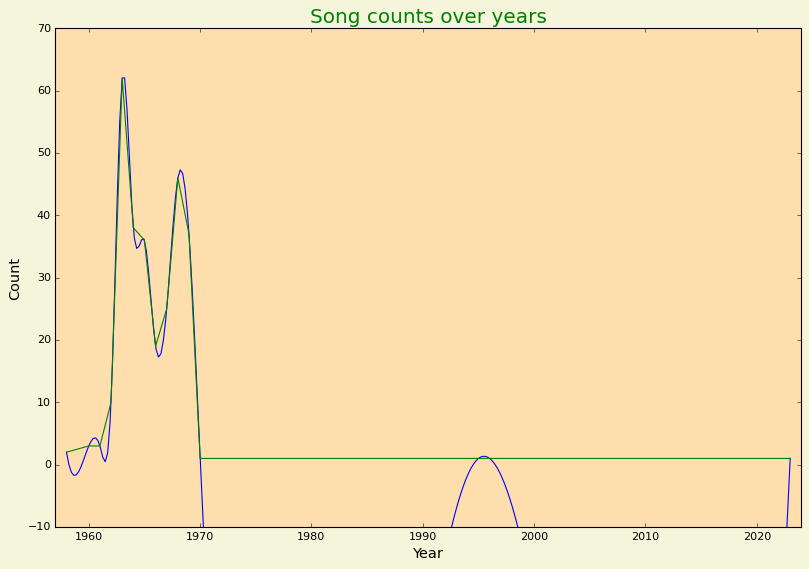

In [12]:
# # 300 represents the number of points to make between T.min and T.max
# T = np.array([6, 7, 8, 9, 10, 11, 12])
# power = np.array([1.53E+03, 5.92E+02, 2.04E+02, 7.24E+01, 2.72E+01, 1.10E+01, 4.70E+00])
#
# # plt.plot(T,power)
# # plt.show()
#
# xnew = np.linspace(T.min(), T.max(), 300)
#
# spl = make_interp_spline(T, power, k=3)  # type: BSpline
# power_smooth = spl(xnew)
#
# plt.plot(xnew, power_smooth)
# plt.show()

from scipy.interpolate import make_interp_spline, BSpline

year_smooth = np.linspace(years.min(), years.max(), 300)
spl = make_interp_spline(years, counts, k=3)  # type: BSpline
counts_smooth = spl(year_smooth)

# plt.figure(layout='constrained', figsize=(5, 3), facecolor='lightyellow', alpha=0.5)
fig, ax = plt.subplots(figsize=(10, 7), layout='constrained', facecolor='beige')

ax.set_facecolor('navajowhite')

plt.ticklabel_format(useOffset=False)

plt.xlim([1957, 2024])
plt.ylim([-10, 70])
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

plt.xlabel('Year', fontsize=13)
plt.ylabel('Count', fontsize=13)
plt.title('Song counts over years', fontsize=18, color='green')

plt.plot(year_smooth, counts_smooth)
plt.plot(years, counts)
plt.show()

# # Alternatively
# ax = plt.axes()
# ax.set(xlim=(years.min()-1, years.max()+1), ylim=(150, 400), xlabel='release year', ylabel='count', title='Song counts over years')
# ax.ticklabel_format(useOffset=False)
# ax.plot(years, counts, color='steelblue', linewidth=2, marker='o', alpha=0.8)
# ax.plot(year_smooth, counts_smooth, color='green', linewidth=2, alpha=0.8);

###### 3. Multiple subplots
(shown here after [this](https://jakevdp.github.io/PythonDataScienceHandbook/04.08-multiple-subplots.html))

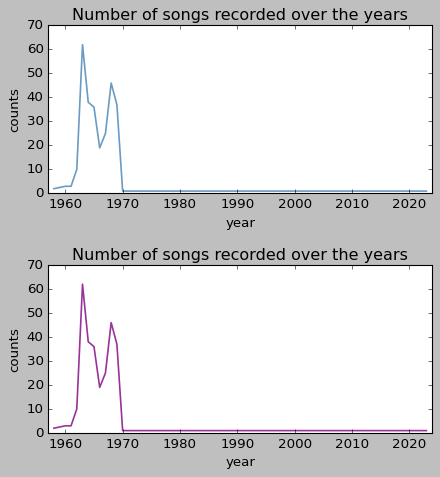

In [20]:
# # From https://jakevdp.github.io/PythonDataScienceHandbook/04.08-multiple-subplots.html
# fig = plt.figure()
# ax1 = fig.add_axes([0.1, 0.55, 0.8, 0.4],
#                    xticklabels=[], ylim=(-1.2, 1.2))
# ax2 = fig.add_axes([0.1, 0.1, 0.8, 0.4],
#                    ylim=(-1.2, 1.2))
# # Meanings of the numbers in [0.1, 0.55, 0.8, 0.4]:
# #     0.1 - distance from the left edge of fig (grey area)
# #     0.55 - distance between the upper and lower subplots (0.5: they touch each other)
# #     0.8 - distance from the right edge of fig (grey area)
# #     0.4 - area assigned to the upper/lower subplot (ax1/ax2) along the vertical axes
# # Experiment with these numbers to get a better feeling for them
#
# x = np.linspace(0, 10)
# ax1.plot(np.sin(x))
# ax2.plot(np.cos(x));
#
# fig, ax = plt.subplots()
# ax
#

fig = plt.figure(figsize=(6, 6), )
# fig
ax1 = fig.add_axes((0.1, 0.579, 0.8, 0.35),
                   xlim=(1957, 2024), ylim=(0, 70),
                   xlabel='year', ylabel='counts',
                   title='Number of songs recorded over the years')
ax2 = fig.add_axes((0.1, 0.08, 0.8, 0.35),
                   xlim=(1957, 2024), ylim=(0, 70),
                   xlabel='year', ylabel='counts',
                   title='Number of songs recorded over the years')
# display(type(ax1))
ax1.ticklabel_format(useOffset=False)
ax2.ticklabel_format(useOffset=False)

ax1.plot(years, counts, color='steelblue', linewidth=1.5, alpha=0.8)    # alpha: transparency (0-1)
ax2.plot(years, counts, color='purple', linewidth=1.5, alpha=0.8);      # alpha: transparency (0-1)

##### Histogram

Read the dataset (`The Beatles songs dataset, visualization.csv`).

In [2]:
songs = pd.read_csv('../data/The Beatles songs dataset, visualization.csv')
songs
# songs.sort_values(['Title'], inplace=True)
# songs

,URI,Title,Year,Album,Popularity,Duration,Key,Mode,Tempo,Time_signature,...,Weeks at No1 in UK (The Guardian),Highest position (Billboard),Weeks at No1 (Billboard),Top 50 (Billboard),Top 50 (Ultimate classic rock),Top 50 (Rolling Stone),Top 50 (NME),Top 50 (Top50songs.org),"Top 50 (USA today, 2017)","Top 50 (Vulture, by Bill Wyman)"
0,spotify:track:2FDEHIMkjxFLzj688M2I3h,(You're So Square) Baby I Don't Care - Studio Jam,1968,The Beatles,29,43,9,1,112.173,4,...,0,0,0,0,0,0,0,0,0,0
1,spotify:track:2HvTGx5fzFGpHSyRNvXd9T,12-bar Original,1965,Anthology 2,31,175,9,1,122.678,4,...,0,0,0,0,0,0,0,0,0,0
2,spotify:track:0hKRSZhUGEhKU6aNSPBACZ,A Day in the Life,1967,Sgt. Pepper's Lonely Hearts Club Band,65,335,4,0,163.219,4,...,0,0,0,0,50,50,49,33,50,50
3,spotify:track:5J2CHimS7dWYMImCHkEFaJ,A Hard Day's Night,1964,A Hard Day's Night,71,152,0,1,138.514,4,...,3,1,2,43,33,40,32,32,36,10
4,spotify:track:5RuE7nwp4TWsRvLXG7Yjy1,A Shot of Rhythm and Blues,1963,Live at the BBC,35,136,2,1,128.919,4,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
280,spotify:track:70HNt0eoBVqr4ss68U8x3B,You're Going to Lose That Girl,1965,Help!,57,140,4,1,131.975,4,...,0,0,0,0,0,24,0,0,0,0
281,spotify:track:4F1AgKpuFRMLEgtPETVwZk,You've Got to Hide Your Love Away,1965,Help!,73,131,7,1,184.267,3,...,0,0,0,0,9,20,2,0,14,5
282,spotify:track:7rgUYidQh5tH0YlXCoKaYJ,You've Really Got a Hold on Me,1963,With the Beatles,54,182,9,1,77.643,4,...,0,0,0,0,0,0,0,0,0,0
283,spotify:track:3FuRBetiFz4ijeLdGCxQ5Y,Young Blood,1963,Live at the BBC,29,116,2,1,68.111,4,...,0,0,0,0,0,0,0,0,0,0


Plot the histogram of song durations (lengths, times).

Use Pandas to extract song lengths as a `pd.Series` object (`<pd.Series object> = <pd.df>['<column>']`).

In [3]:
# Get the song lengths as a pd.Series object
durations = songs.Duration
durations

0       43
1      175
2      335
3      152
4      136
      ... 
280    140
281    131
282    182
283    116
284    149
Name: Duration, Length: 285, dtype: int64

In [4]:
# Convert the song lengths into a NumPy array (using <song lengths>.to_numpy() or np.array(<song lengths>))
durations = durations.to_numpy()
durations

array([ 43, 175, 335, 152, 136, 163, 230, 139, 133, 124, 124, 185, 130,
       237, 152, 121, 168, 124, 133, 144, 162, 122, 183, 163, 141, 106,
       165, 157, 157, 162, 139, 235, 144, 142, 131, 156,  96,  74, 143,
       158, 137, 160, 258, 150, 183, 142, 131, 170, 236, 147,  51, 232,
       145, 116, 135, 149, 125, 215, 231, 148, 164, 128, 121, 144, 143,
       146, 137, 121, 152, 266, 116, 194, 167, 153, 113, 137,  91, 129,
       161, 191, 144, 147,  73, 163, 100, 207, 138, 270,  23, 186, 145,
       194, 431, 152, 173, 161, 117, 273, 129, 153, 145, 126, 168, 118,
       168, 145, 148, 175, 164, 103, 467, 144, 149, 106, 140, 118, 129,
       106, 124, 153, 122, 118, 147, 182, 123, 112, 151, 217, 127, 142,
       143, 168, 148, 164, 133, 388, 115, 171, 174, 145, 163, 151, 136,
       176, 110, 243, 155, 108, 156, 130, 184, 238, 142, 181, 162, 110,
       208,  40, 171, 116, 148, 117, 207,  66, 136, 160, 107, 167,  50,
       168, 155, 162, 135, 125, 202, 128, 180, 248, 164, 187, 16

###### Plotting using Matplotlib

[Matplotlib histogram example](https://matplotlib.org/stable/gallery/statistics/hist.html)

Plot the histogram of the song lengths using Matplotlib.

Minimal version: `plt.hist(<x>, bins=<number of bins>);` or `sb.histplot(<x>, bins=<number of bins>)`.

Alternatively:<br>
`plt.figure(layout='constrained', facecolor='<color>', figsize=(3.5, 2), )`<br>
`ax = plt.axes()`<br>
`ax.set(xlabel='...', ylabel='...', title='...')`<br>
`ax.hist(<x>, bins=<number of bins>)`<br>

As for the plot styles, there are a lot of [available styles](https://www.dunderdata.com/blog/view-all-available-matplotlib-styles) that can be also shown in code using `plt.style.available`. See also [this](https://www.analyticsvidhya.com/blog/2021/08/exploring-matplotlib-stylesheets-for-data-visualization/).

Alternatively, plot style can be set using `sb.set_theme(palette='...')` (or just `sb.set()`, but that function might get deprecated and removed from *Seaborn* in the future). See [`sb.set_theme()` documentation](https://seaborn.pydata.org/generated/seaborn.set_theme.html) for the function's parameters and defaults. For `palette='...'` use any of the palettes shown with `plt.style.available`, or any of [these](https://matplotlib.org/stable/users/explain/colors/colormaps.html#qualitative), or...

Elaborated version, using plt.subplots():

Get the Figure and the Axes objects

`fig, ax = plt.subplots(nrows=1, ncols=1, layout='constrained', facecolor='color', figsize=(<x_size>, <y_size>))`

Plot the data on the Axes

`ax.hist(x=<x>, bins=<number of bins>, color='<color>', linewidth=<linewidth>, edgecolor='<edgecolors>', alpha=<transparency>)`

Set the Axes title, background color (face color), labels (incl. font sizes) and limits

`ax.set_title('<title>', fontsize=12, loc='left')`<br>
`ax.set_facecolor('<color>')`<br>
`ax.set_xlabel('<x_label>', fontsize=8)`<br>
`ax.set_ylabel('<y_label>', fontsize=8)`<br>
`ax.set_xlim(<m>, <n>)`<br>
`ax.set_ylim(<p>, <q>)`<br>

Set the tick parameters<br>

`ax.ticklabel_format(useOffset=False)`<br>
`ax.tick_params(axis='x', labelsize=6)`<br>
`ax.tick_params(axis='y', labelsize=6)`<br>

Display the plot<br>

`plt.show()`<br><br>

In `fig, ax = plt.subplots(nrows=1, ncols=1, layout='constrained', facecolor='color', figsize=(<x_size>, <y_size>))`, using `layout='constrained'` is recommended to avoid overlapping of figure elements when changing the figure size. For a good figure size, use `figsize=(3.5, 2)` or similar.

To prevent numbers displayed in scientific notation (exponential) on axes ticks, make sure to use `ax.ticklabel_format(useOffset=False)`.

Experiment with different font sizes for labels, title and ticks.

The `color` parameter can be abbreviated as `c` and is optional. The `marker` parameter is optional as well, and so is `edgecolor` (can be abbreviated as `ec`). They all have defaults. For other values of `color` and `marker`, see [this](https://matplotlib.org/stable/gallery/color/named_colors.html#css-colors) and [this](https://matplotlib.org/stable/api/_as_gen/matplotlib.markers.MarkerStyle.html#matplotlib.markers.MarkerStyle.markers), respectively.

Examples of some parameters in `ax.hist()`: `color='steelblue'`, `linewidth=1` (the thickness of the dots/points rim), `alpha=0.8` (alpha: transparency (0-1)).

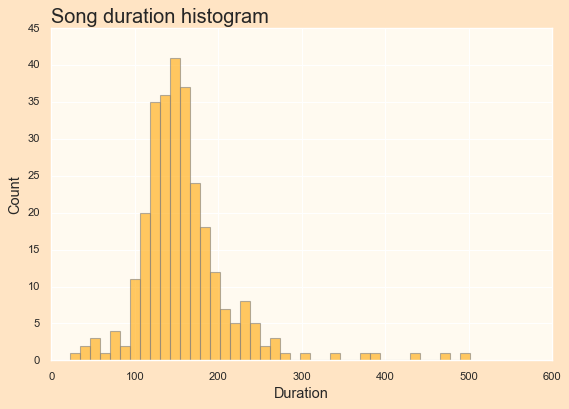

In [5]:
# Set plot style using sb.set_theme(palette='Pastel2')
sb.set_theme(palette='Pastel1')

# Plot the histogram - x: song time in [sec]; y: number of songs; 40 bins

# # Minimal version
# plt.hist(durations, bins=40);
# # A more detailed version
# plt.figure(layout='constrained', facecolor='bisque', figsize=(7, 5), )
# ax = plt.axes()
# ax.set(xlabel='Duration', ylabel='Count', title='Song duration histogram')
# ax.hist(durations, bins=40);

# Elaborated version, using plt.subplots()
# Get the Figure and the Axes objects
fig, ax = plt.subplots(nrows=1, ncols=1, layout='constrained', facecolor='bisque', figsize=(7, 5))

# Plot the data on the Axes
ax.hist(x=durations, bins=40, color='orange', linewidth=1, edgecolor='grey', alpha=0.6)

# Set the Axes title, background color (face color), labels (incl. font sizes) and limits
ax.set_title('Song duration histogram', fontsize=18, loc='left')
ax.set_facecolor('floralwhite')
ax.set_xlabel('Duration', fontsize=13)
ax.set_ylabel('Count', fontsize=13)
ax.set_xlim(0, 600)
ax.set_ylim(0, 45)

# Set the tick parameters

ax.ticklabel_format(useOffset=False)
ax.tick_params(axis='x', labelsize=10)
ax.tick_params(axis='y', labelsize=10)

# Display the plot

plt.show()


##### Bar graph

Read the dataset (`'../data/The Beatles songs, visualization.csv'`) and make some minor transformations.

`pd.read_csv()` returns a `pd.DataFrame` object.

As for specifying the path of the dataset properly, see [this](https://stackoverflow.com/questions/35384358/how-to-open-my-files-in-data-folder-with-pandas-using-relative-path) (more specifically, **both** [this](https://stackoverflow.com/a/35384414/1899061) and [this](https://stackoverflow.com/a/43600253/1899061)).

In [6]:
# Get the songs as a pd.DataFrame object from 'data/The Beatles songs, visualization.csv', or from
# '../data/The Beatles songs dataset, visualization.csv', or '../../data/The Beatles songs, visualization.csv', or ...,
# depending on where the csv file is located
songs = pd.read_csv('../data/The Beatles songs dataset, visualization.csv')
songs

,URI,Title,Year,Album,Popularity,Duration,Key,Mode,Tempo,Time_signature,...,Weeks at No1 in UK (The Guardian),Highest position (Billboard),Weeks at No1 (Billboard),Top 50 (Billboard),Top 50 (Ultimate classic rock),Top 50 (Rolling Stone),Top 50 (NME),Top 50 (Top50songs.org),"Top 50 (USA today, 2017)","Top 50 (Vulture, by Bill Wyman)"
0,spotify:track:2FDEHIMkjxFLzj688M2I3h,(You're So Square) Baby I Don't Care - Studio Jam,1968,The Beatles,29,43,9,1,112.173,4,...,0,0,0,0,0,0,0,0,0,0
1,spotify:track:2HvTGx5fzFGpHSyRNvXd9T,12-bar Original,1965,Anthology 2,31,175,9,1,122.678,4,...,0,0,0,0,0,0,0,0,0,0
2,spotify:track:0hKRSZhUGEhKU6aNSPBACZ,A Day in the Life,1967,Sgt. Pepper's Lonely Hearts Club Band,65,335,4,0,163.219,4,...,0,0,0,0,50,50,49,33,50,50
3,spotify:track:5J2CHimS7dWYMImCHkEFaJ,A Hard Day's Night,1964,A Hard Day's Night,71,152,0,1,138.514,4,...,3,1,2,43,33,40,32,32,36,10
4,spotify:track:5RuE7nwp4TWsRvLXG7Yjy1,A Shot of Rhythm and Blues,1963,Live at the BBC,35,136,2,1,128.919,4,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
280,spotify:track:70HNt0eoBVqr4ss68U8x3B,You're Going to Lose That Girl,1965,Help!,57,140,4,1,131.975,4,...,0,0,0,0,0,24,0,0,0,0
281,spotify:track:4F1AgKpuFRMLEgtPETVwZk,You've Got to Hide Your Love Away,1965,Help!,73,131,7,1,184.267,3,...,0,0,0,0,9,20,2,0,14,5
282,spotify:track:7rgUYidQh5tH0YlXCoKaYJ,You've Really Got a Hold on Me,1963,With the Beatles,54,182,9,1,77.643,4,...,0,0,0,0,0,0,0,0,0,0
283,spotify:track:3FuRBetiFz4ijeLdGCxQ5Y,Young Blood,1963,Live at the BBC,29,116,2,1,68.111,4,...,0,0,0,0,0,0,0,0,0,0


How many cheerful songs did The Beatles release?

Define a new feature (column in the `songs` dataframe), `Cheerful`, as a combination of, e.g., `Danceability`, `Energy`, `Valence` and `Mode` - songs with `Danceability`, `Energy` and `Valence` above the corresponding 3rd quartiles and with `Mode = 1` (major key) are considered cheerful. It is also possible to include low `Acousticness` and low `Instrumentalness` as criteria for cheerful songs.

In [7]:
# Run songs.describe() to see the 3rd quartiles
songs.describe()
# songs.describe()[['Acousticness', 'Instrumentalness']]

,Year,Popularity,Duration,Key,Mode,Tempo,Time_signature,Valence,Danceability,Energy,...,Weeks at No1 in UK (The Guardian),Highest position (Billboard),Weeks at No1 (Billboard),Top 50 (Billboard),Top 50 (Ultimate classic rock),Top 50 (Rolling Stone),Top 50 (NME),Top 50 (Top50songs.org),"Top 50 (USA today, 2017)","Top 50 (Vulture, by Bill Wyman)"
count,285.000000,285.000000,285.000000,285.000000,285.000000,285.000000,285.000000,285.000000,285.000000,285.000000,...,285.000000,285.000000,285.000000,285.000000,285.000000,285.000000,285.000000,285.000000,285.000000,285.000000
mean,1965.863158,50.280702,158.912281,5.007018,0.852632,121.286316,3.859649,0.692713,0.529147,0.570933,...,0.235088,1.550877,0.189474,4.417544,4.305263,4.375439,4.350877,4.473684,4.473684,3.757895
std,4.878692,14.477222,57.155915,3.378675,0.355096,28.612415,0.461115,0.233140,0.130620,0.188987,...,1.033334,5.838951,0.930259,11.430641,11.154870,11.365383,11.307001,11.448146,11.448146,10.886142
min,1958.000000,22.000000,23.000000,0.000000,0.000000,59.004000,1.000000,0.037800,0.146000,0.079600,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1963.000000,39.000000,128.000000,2.000000,1.000000,97.871000,4.000000,0.553000,0.440000,0.457000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,1965.000000,52.000000,150.000000,5.000000,1.000000,123.227000,4.000000,0.735000,0.538000,0.571000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,1968.000000,60.000000,175.000000,9.000000,1.000000,137.717000,4.000000,0.886000,0.629000,0.724000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,2023.000000,87.000000,502.000000,11.000000,1.000000,209.242000,5.000000,0.979000,0.880000,0.983000,...,7.000000,47.000000,9.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000


In [8]:
# Display the 3rd quartiles for selected candidate features to describe the new feature, 'Cheerful'
# ('Danceability', 'Energy', 'Liveness', 'Loudness', 'Tempo', 'Valence')
songs.describe().loc['75%', ['Danceability', 'Energy', 'Valence']]

Danceability    0.629
Energy          0.724
Valence         0.886
Name: 75%, dtype: float64

In [9]:
# Define threshold values for the candidate features (3rd quartiles, i.e. '75%')
thresholds_high = songs.describe().loc['75%', :][['Danceability', 'Energy', 'Valence', ]]
thresholds_high
thresholds_low = songs.describe().loc['25%', :][['Acousticness', 'Instrumentalness']]
thresholds_low

Acousticness        0.112
Instrumentalness    0.000
Name: 25%, dtype: float64

In [10]:
# Define the condition for a song to be cheerful (songs with Valence above the corresponding 3rd quartile and with Mode = 1);
# experiment with different combinations of candidate features
cheerful = (
            (songs.Valence >= thresholds_high['Valence']) &
            # (songs.Acousticness <= thresholds_low['Acousticness']) &
            (songs.Mode == 1))
cheerful.sum()

np.int64(66)

In [12]:
# Define the new feature, 'Cheerful'
songs['Cheerful'] = 'No'
songs.loc[cheerful, 'Cheerful'] = 'Yes'
songs

,URI,Title,Year,Album,Popularity,Duration,Key,Mode,Tempo,Time_signature,...,Highest position (Billboard),Weeks at No1 (Billboard),Top 50 (Billboard),Top 50 (Ultimate classic rock),Top 50 (Rolling Stone),Top 50 (NME),Top 50 (Top50songs.org),"Top 50 (USA today, 2017)","Top 50 (Vulture, by Bill Wyman)",Cheerful
0,spotify:track:2FDEHIMkjxFLzj688M2I3h,(You're So Square) Baby I Don't Care - Studio Jam,1968,The Beatles,29,43,9,1,112.173,4,...,0,0,0,0,0,0,0,0,0,No
1,spotify:track:2HvTGx5fzFGpHSyRNvXd9T,12-bar Original,1965,Anthology 2,31,175,9,1,122.678,4,...,0,0,0,0,0,0,0,0,0,No
2,spotify:track:0hKRSZhUGEhKU6aNSPBACZ,A Day in the Life,1967,Sgt. Pepper's Lonely Hearts Club Band,65,335,4,0,163.219,4,...,0,0,0,50,50,49,33,50,50,No
3,spotify:track:5J2CHimS7dWYMImCHkEFaJ,A Hard Day's Night,1964,A Hard Day's Night,71,152,0,1,138.514,4,...,1,2,43,33,40,32,32,36,10,No
4,spotify:track:5RuE7nwp4TWsRvLXG7Yjy1,A Shot of Rhythm and Blues,1963,Live at the BBC,35,136,2,1,128.919,4,...,0,0,0,0,0,0,0,0,0,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
280,spotify:track:70HNt0eoBVqr4ss68U8x3B,You're Going to Lose That Girl,1965,Help!,57,140,4,1,131.975,4,...,0,0,0,0,24,0,0,0,0,No
281,spotify:track:4F1AgKpuFRMLEgtPETVwZk,You've Got to Hide Your Love Away,1965,Help!,73,131,7,1,184.267,3,...,0,0,0,9,20,2,0,14,5,No
282,spotify:track:7rgUYidQh5tH0YlXCoKaYJ,You've Really Got a Hold on Me,1963,With the Beatles,54,182,9,1,77.643,4,...,0,0,0,0,0,0,0,0,0,No
283,spotify:track:3FuRBetiFz4ijeLdGCxQ5Y,Young Blood,1963,Live at the BBC,29,116,2,1,68.111,4,...,0,0,0,0,0,0,0,0,0,Yes


In [13]:
# Display these cheerful songs
songs.loc[songs.Cheerful == 'Yes', ['Title', 'Cheerful']]

,Title,Cheerful
4,A Shot of Rhythm and Blues,Yes
7,Act Naturally,Yes
15,And Your Bird Can Sing,Yes
29,Birthday,Yes
35,Carol,Yes
...,...,...
255,Two of Us,Yes
264,Why Don't We Do It in the Road?,Yes
273,You Can't Do That,Yes
276,You Like Me Too Much,Yes


How many Beatles songs have been cheerful, in terms of the definition of `songs.Cheerful` shown above?

In [14]:
songs.Cheerful.value_counts()

Cheerful
No     219
Yes     66
Name: count, dtype: int64

<u>Save this version as a new *.csv* file, for use in the subsequent examples.</u> (`<pd.df>.to_csv('<path>')`)

In [15]:
songs.to_csv('../data/The Beatles songs dataset, cheerful.csv', index=False)

###### Preparing the data for plotting the bar graph

Group the data - group the songs by years.

In [16]:
songs_by_years = songs.groupby('Year')

Use `get_group(<year>)` to get all songs from a certain year and `value_counts()` over the resulting group's `Cheerful` column (showing the `Yes` and `No` subgroups). This is a precursor to creating the data for the y-axis of the bar graph.

In [17]:
songs_by_years.get_group(1966)
songs_by_years.get_group(1966).value_counts('Cheerful')
songs_by_years.get_group(1966).value_counts('Cheerful')['Yes']

np.int64(1)

Build the data to plot by extracting relevant items from each group.

For x-axis, use `unique()` over the `Year` column, and then sort the resulting array using `np.sort()`, or just call `<years>.sort()`.

In [18]:
np.sort(songs.Year.unique())

array([1958, 1960, 1961, 1962, 1963, 1964, 1965, 1966, 1967, 1968, 1969,
       1970, 1995, 1996, 2023])

In [19]:
years = songs.Year.unique()
years.sort()
years

array([1958, 1960, 1961, 1962, 1963, 1964, 1965, 1966, 1967, 1968, 1969,
       1970, 1995, 1996, 2023])

For y-axis, create the lists of cheerful songs (`cheerful`) and of the other ones (`not_cheerful`).
(Start from two empty lists. Loop over the sorted list of years created in the previous step, `get_group()` for each year and append the `value_counts()['Yes']` of the `Cheerful` column of the current year (`y['Cheerful']`) to `cheerful` if any of `y['Cheerful']` has the value `Yes`, otherwise append 0. Do the similar thing for `not_cheerful`. Display both lists in the end to double-check the result.)

In [20]:
cheerful = []
not_cheerful = []
for y in years:
    s = songs_by_years.get_group(y)
    cheerful.append(s.value_counts('Cheerful')['Yes'] if any(s.Cheerful == 'Yes') else 0)
    not_cheerful.append(s.value_counts('Cheerful')['No'] if any(s.Cheerful == 'No') else 0)
print(np.array(cheerful))
print(np.array(not_cheerful))

[ 1  0  0  0 34 12  6  1  1  6  5  0  0  0  0]
[ 1  3  3 10 28 26 30 18 24 40 32  1  1  1  1]


And now plot the bar graph. Based on the second example from [here](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.plot.bar.html) (using `<pd.df>.plot.bar()`, not Matplotlib or Seaborn).
For a complete list of parameters used in `**kwargs`, see [this](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.plot.html).
For a list of named colors (Matplotlib named colors), see [here](https://matplotlib.org/stable/gallery/color/named_colors.html#css-colors).

First create an auxiliary dataframe to use for plotting. Use `pwerful` and `not_powerful` as the columns, <u>and the list of artists created above as the index of the dataframe</u>.

In [21]:
# # The role-model example from https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.plot.bar.html
# speed = [0.1, 17.5, 40, 48, 52, 69, 88]
# lifespan = [2, 8, 70, 1.5, 25, 12, 28]
# index = ['snail', 'pig', 'elephant', 'rabbit', 'giraffe', 'coyote', 'horse']
# df = pd.DataFrame({'speed': speed, 'lifespan': lifespan}, index=index)
df = pd.DataFrame({'cheerful': cheerful, 'not_cheerful': not_cheerful}, index=years)


###### Alternative 1 - plotting the bargraph using Pandas (`<pd.df>.plot.bar()`)

[Pandas bargraph example](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.plot.bar.html)

Use `ax = <pd.df>.plot.bar()` to plot the bargraph.

Relevant parameters:
- `figsize=(<width>, <height>)` (e.g., (6, 6))
- `rot=<rotation angle [degrees]>` for the x-axis labels
- `ylim=(<from>, <to>)`
- `color={'powerful': 'limegreen', 'not_powerful': 'navajowhite'}` (for a list of Matplotlib named colors, see [here](https://matplotlib.org/stable/gallery/color/named_colors.html#css-colors))
- `edgecolor='<color of bin lines>'`
- `title='<title>'`
- `xlabel='<xlabel>'`
- `ylabel='<ylabel>'`
- `fontsize=<fontsize>` (for all text; suitable fontsizes are 10, 12,...)
- `stacked=True` (the bins for the same x-axis value stacked on top of one another)

Alternatively, set just a few parameters within ``, and use the relevant `Axes` methods for the rest:

Set the Axes title, background color (face color), labels (incl. font sizes) and limits

`ax.set_title('<title>', fontsize=12, loc='left')`<br>
`ax.set_facecolor('<color>')`<br>
`ax.set_xlabel('<x_label>', fontsize=8)`<br>
`ax.set_ylabel('<y_label>', fontsize=8)`<br>
`ax.set_xlim(<m>, <n>)`<br>
`ax.set_ylim(<p>, <q>)`<br>

Set the tick parameters<br>

`ax.ticklabel_format(useOffset=False)`<br>
`ax.tick_params(axis='x', labelsize=6)`<br>
`ax.tick_params(axis='y', labelsize=6)`<br>

Display the plot<br>

`plt.show()`<br><br>

To show labels (counts) in each bin container, use:

`for c in ax.containers:`<br>
&emsp;&emsp;`ax.bar_label(c, label_type='center')`

If the labels (counts) in each container are not needed, the returned value (`ax`) is usually unnecessary and can be omitted.

It is <b>a very good idea</b> to also use `plt.tight_layout()` <b>after</b> `<pd.df>.plot.bar()` to avoid cutoffs at the bottom of the figure.

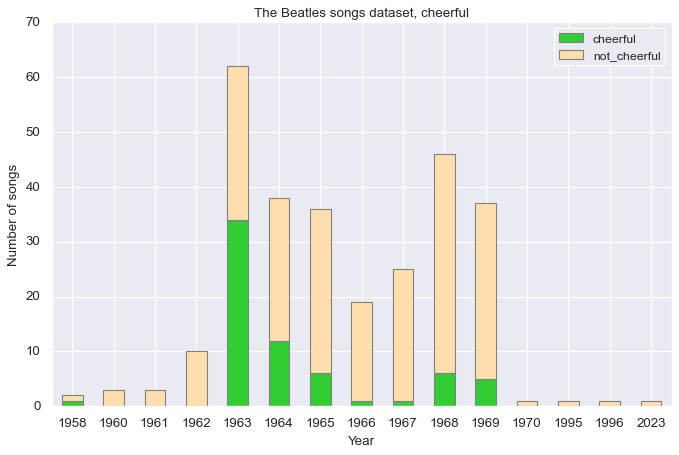

In [22]:
ax = df.plot.bar(
    figsize=(10, 6),
    rot=0,
    ylim=(0, 70),
    color={'cheerful': 'limegreen', 'not_cheerful': 'navajowhite'},
    edgecolor='grey',
    title='The Beatles songs dataset, cheerful',
    xlabel='Year',
    ylabel='Number of songs',
    fontsize=12,
    stacked=True,
)

###### Alternative 2 - plotting the bargraph using Seaborn (`sb.countplot()`)

Use `ax = sb.countplot()` to plot the bargraph.

Relevant parameters:
- `data=<pd.df>`
- `x='<column 1>'` (e.g., 'artists')
- `hue='<column 2>'` (e.g., 'powerful`)
- `palette='<palette>'` (e.g., 'Set2'; it is also possible to define custom palletes using Hex codes, e.g. `palette=['#432371','#FAAE7B']`)
- `dodge=False` to make the bargraph **seemingly stacked** (the containers are not on top of each other, they just overlap); if no stacking is needed (which is a recommended option here), hust omit `dodge=False`

**Making the bargraph really stacked (its containers on top of each other) uses (`dodge=False`), but it cannot be done directly (no kwarg for that, i.e. no specific feature for that in `Seaborn.countplot()`), only with some extra work** (see a possible solution [here](https://stackoverflow.com/a/67116235/1899061)).

If necessary, use `plt.xticks(rotation=<rotation angle [degrees]>)` before `sb.countplot()`.

Note that `ax = sb.countplot()` returns a `pd.Axes` object, so after the call to `ax = sb.countplot()` all `pd.Axes` methods can be called (like `ax.set_title(title='<title>'`, `ax.set_ylim(...)`, etc.).

To show labels (counts) in each bin container, use:

`for c in ax.containers:`<br>
&emsp;&emsp;`ax.bar_label(c, label_type='center')`

If the labels (counts) in each container are not needed, the returned value (`ax`) is usually unnecessary and can be omitted.



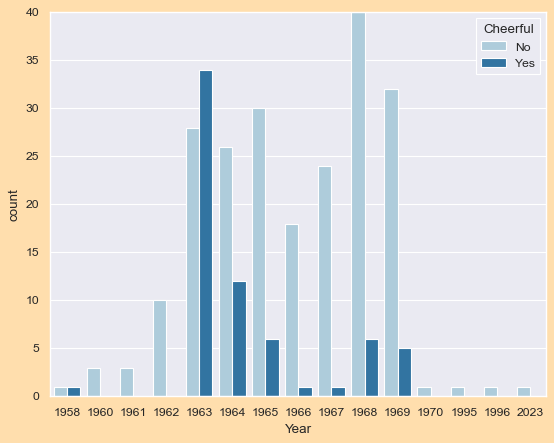

In [23]:
plt.figure(figsize=(8, 6), facecolor='navajowhite')
# plt.xticks(rotation=90)

ax = sb.countplot(data=songs, x='Year', hue='Cheerful', palette='Paired', dodge=True)
# Alternatively, palette=['navajowhite', 'limegreen', ] or something like that

##### Box plot
[Seaborn boxplot example](https://seaborn.pydata.org/generated/seaborn.boxplot.html) (used here as the role model)

For Seaborn color palette names see [this](https://seaborn.pydata.org/generated/seaborn.color_palette.html#seaborn.color_palette) or [this](https://10xsoft.org/courses/data-analysis/mastering-data-visualization-with-python/section-4-data-visualization-using-seaborn/colour-palettes-seaborn/). To list the names of some ('quantitative') Seaborn color palettes, use `sb.palettes.SEABORN_PALETTES.keys()` (see [this](https://10xsoft.org/courses/data-analysis/mastering-data-visualization-with-python/section-4-data-visualization-using-seaborn/colour-palettes-seaborn/) and [this](https://www.codecademy.com/article/seaborn-design-ii) for additional named palettes).

Read the dataset (`'data/The Beatles songs, visualization.csv'`).

`pd.read_csv()` returns a `pd.DataFrame` object.

As for specifying the path of the dataset properly, see [this](https://stackoverflow.com/questions/35384358/how-to-open-my-files-in-data-folder-with-pandas-using-relative-path) (more specifically, **both** [this](https://stackoverflow.com/a/35384414/1899061) and [this](https://stackoverflow.com/a/43600253/1899061)).

In [24]:
# Get the songs as a pd.DataFrame object from 'data/The Beatles songs, visualization.csv', or from
# '../data/The Beatles songs, visualization.csv', or '../../data/The Beatles songs, visualization.csv', or ..., depending on where the csv file is located
songs: pd.DataFrame = pd.DataFrame(pd.read_csv('../data/The Beatles songs dataset, visualization.csv'))

Use `sb.boxplot(y='<column>' | x='<column>', palette='<palette>', hue=1, legend=False)` to plot some boxplots.

For a single-column boxplot, relevant parameters are `y=<pd.df>['column']` (for 'vertical' boxplot) or `x=<pd.df>['column']` (for 'horizontal' boxplot), and `palette='<palette>'` (e.g., 'Set3', 'pastel', ...; see the links above for other named color palettes). <u>Note that in case `palette` is used, it is also necessary to use `hue=<n>`, where `<n>` can be any value, e.g. 1</u>.

For a multiple-column boxplot, relevant parameters are `data=<pd.df>[['column1', 'column2',...]]`, `orient='v'` (for 'vertical' boxplot) and `palette='<palette>'`. No `hue` is needed, no `legend`.

dict_keys(['deep', 'deep6', 'muted', 'muted6', 'pastel', 'pastel6', 'bright', 'bright6', 'dark', 'dark6', 'colorblind', 'colorblind6'])

<Axes: xlabel='Mode', ylabel='Duration'>

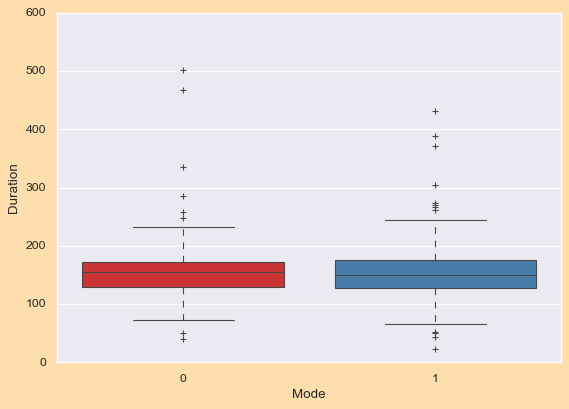

In [25]:
display(sb.palettes.SEABORN_PALETTES.keys())

plt.figure(layout='constrained', facecolor='navajowhite', figsize=(7, 5), )

# # For a single column (e.g., duration)
# sb.boxplot(y=songs.Duration, palette='Set1', hue=1, legend=False)
# # plt.tight_layout()

# Alternatively
sb.boxplot(data=songs, x='Mode', y='Duration', palette='Set1', hue='Mode', legend=False)

# # For multiple columns (e.g., Energy and Acousticness)
# sb.boxplot(data=songs[['Energy', 'Acousticness']], palette='Set1', legend=False)


##### Violin plot
[Seaborn violin plot example](https://seaborn.pydata.org/generated/seaborn.violinplot.html)

Combines box plot and density plot. Based on [this](https://stackoverflow.com/questions/46134113/seaborn-violin-plot-from-pandas-dataframe-each-column-its-own-separate-violin-p) and [this](https://seaborn.pydata.org/generated/seaborn.violinplot.html).

Read the dataset (`'../data/The Beatles songs, visualization.csv'`).

`pd.read_csv()` returns a `pd.DataFrame` object.

As for specifying the path of the dataset properly, see [this](https://stackoverflow.com/questions/35384358/how-to-open-my-files-in-data-folder-with-pandas-using-relative-path) (more specifically, **both** [this](https://stackoverflow.com/a/35384414/1899061) and [this](https://stackoverflow.com/a/43600253/1899061)).

In [26]:
# Get the songs as a pd.DataFrame object from ''../data/The Beatles songs, visualization.csv'', or from
# '../data/The Beatles songs, visualization.csv', or '../../data/The Beatles songs, visualization.csv', or ..., depending on where the csv file is located
songs = pd.DataFrame(pd.read_csv('../data/The Beatles songs dataset, visualization.csv'))


Use `sb.violinplot()` like: `x=<pd.df>.loc[<index>, '<column for x-axis>']`, `sb.violinplot(data=<pd.df>, x=x, y=<pd.df>['<column for y-axis>'], hue=x, palette='<palette>', legend=False)`.

For example, if the violin plot should represent density/boxplot diagram of song `duration` in certain `release_year`s, then `<column for x-axis>` is `release_year` and `<column for y-axis>` is `duration`. Good values for `'<palette>'` are, e.g., 'Set3', 'pastel',...).

It is a good practice to set the `x` parameter directly before the call to `sb.violinplot()`, and then use `x=x` in `sb.violinplot()`. Using `x=<pd.df>.loc[<index>, '<column for x-axis>']` within the call to `sb.violinplot()` (like call to `sb.violinplot(x=<pd.df>.loc[<index>, '<column for x-axis>'], y=..., ...)`) might generate an error.

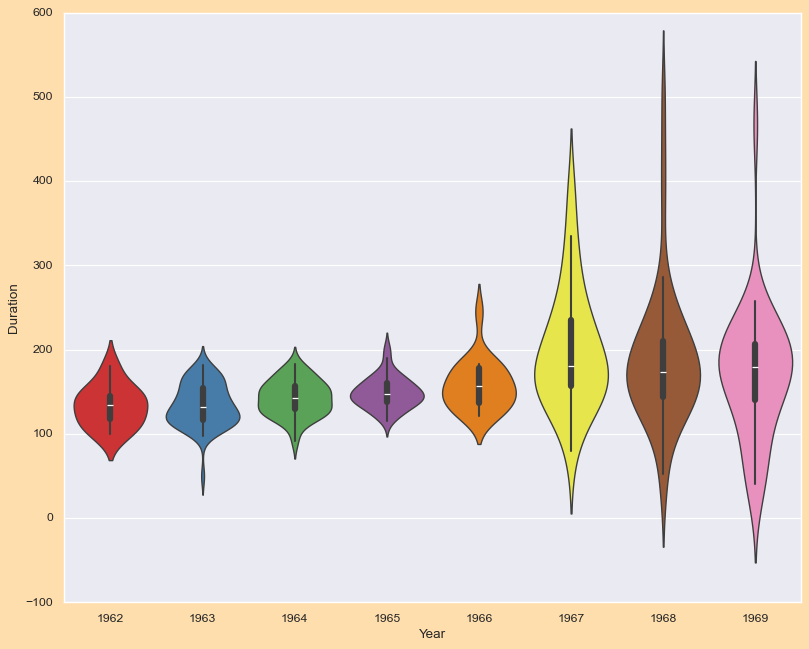

In [27]:
plt.figure(layout='constrained', facecolor='navajowhite', figsize=(10, 8), )

# sb.violinplot(data=songs, x='Year', y='Duration', palette='Set3', hue='Year', legend=False, );

# Alternatively, set x and y explicitly and then call sb.violinplot() as
# sb.violinplot(data=songs, x=x, y=y, hue=x, palette='Set1', legend=False);
filtered_songs = songs[(songs.Year < 1970) & (songs.Year > 1961)]
x=filtered_songs.Year
y=filtered_songs.Duration
sb.violinplot(data=filtered_songs, x=x, y=y, hue=x, palette='Set1', legend=False, );

##### Heat map
[Seaborn heat map example](https://seaborn.pydata.org/generated/seaborn.heatmap.html) (used here as the role model)

To create a heatmap, create the corresponding pivot table first. [An intuitive visual explanation of pivot tables](https://support.microsoft.com/en-us/office/overview-of-pivottables-and-pivotcharts-527c8fa3-02c0-445a-a2db-7794676bce96#:~:text=A%20PivotTable%20is%20an%20interactive,unanticipated%20questions%20about%20your%20data.) (start from [this raw table](https://support.microsoft.com/en-us/office/create-a-pivottable-to-analyze-worksheet-data-a9a84538-bfe9-40a9-a8e9-f99134456576), and then see [the corresponding pivot table](https://support.microsoft.com/en-us/office/overview-of-pivottables-and-pivotcharts-527c8fa3-02c0-445a-a2db-7794676bce96#:~:text=A%20PivotTable%20is%20an%20interactive,unanticipated%20questions%20about%20your%20data.) (expand <em>About Pivot Tables</em>)).


Read the dataset (`'../data/The Beatles songs, visualization.csv'`).

`pd.read_csv()` returns a `pd.DataFrame` object.

As for specifying the path of the dataset properly, see [this](https://stackoverflow.com/questions/35384358/how-to-open-my-files-in-data-folder-with-pandas-using-relative-path) (more specifically, **both** [this](https://stackoverflow.com/a/35384414/1899061) and [this](https://stackoverflow.com/a/43600253/1899061)).

In [35]:
# Get the songs as a pd.DataFrame object from ''../data/The Beatles songs, visualization.csv'', or from
# '../data/The Beatles songs, visualization.csv', or '../../data/The Beatles songs, visualization.csv', or ..., depending on where the csv file is located
songs = pd.read_csv('../data/The Beatles songs dataset, visualization.csv')
songs.head(10)

,URI,Title,Year,Album,Popularity,Duration,Key,Mode,Tempo,Time_signature,...,Weeks at No1 in UK (The Guardian),Highest position (Billboard),Weeks at No1 (Billboard),Top 50 (Billboard),Top 50 (Ultimate classic rock),Top 50 (Rolling Stone),Top 50 (NME),Top 50 (Top50songs.org),"Top 50 (USA today, 2017)","Top 50 (Vulture, by Bill Wyman)"
0,spotify:track:2FDEHIMkjxFLzj688M2I3h,(You're So Square) Baby I Don't Care - Studio Jam,1968,The Beatles,29,43,9,1,112.173,4,...,0,0,0,0,0,0,0,0,0,0
1,spotify:track:2HvTGx5fzFGpHSyRNvXd9T,12-bar Original,1965,Anthology 2,31,175,9,1,122.678,4,...,0,0,0,0,0,0,0,0,0,0
2,spotify:track:0hKRSZhUGEhKU6aNSPBACZ,A Day in the Life,1967,Sgt. Pepper's Lonely Hearts Club Band,65,335,4,0,163.219,4,...,0,0,0,0,50,50,49,33,50,50
3,spotify:track:5J2CHimS7dWYMImCHkEFaJ,A Hard Day's Night,1964,A Hard Day's Night,71,152,0,1,138.514,4,...,3,1,2,43,33,40,32,32,36,10
4,spotify:track:5RuE7nwp4TWsRvLXG7Yjy1,A Shot of Rhythm and Blues,1963,Live at the BBC,35,136,2,1,128.919,4,...,0,0,0,0,0,0,0,0,0,0
5,spotify:track:7fh53ta3vAOGJMQ4i5tCHe,A Taste of Honey,1963,Please Please Me,51,163,1,0,101.408,3,...,0,0,0,0,0,0,0,0,0,0
6,spotify:track:4dkoqJrP0L8FXftrMZongF,Across the Universe,1968,Let It Be,69,230,1,1,152.126,4,...,0,0,0,0,0,0,44,21,19,0
7,spotify:track:0IxxqsYBcCHEQ1HqLYJnwx,Act Naturally,1965,Help!,52,139,7,1,93.020,4,...,0,47,0,1,0,0,0,0,0,0
8,spotify:track:3OUpVpFeNx5jeInhHqiNfs,Ain't She Sweet,1961,Anthology 1,38,133,4,1,77.967,4,...,0,19,0,10,0,0,0,0,0,0
9,spotify:track:5tztLBvTlNC15Np2tnQ5Ll,All I've Got to Do,1963,With the Beatles,55,124,1,0,119.403,4,...,0,0,0,0,0,0,0,0,0,0


The idea: categorize songs according to their *valence*.

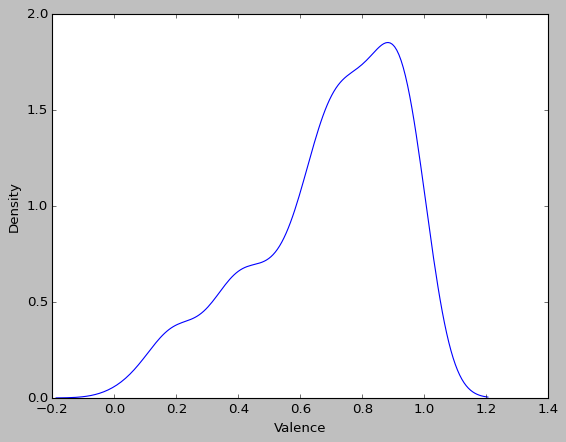

In [37]:
# Plot the density function for 'Valence', using sb.kdeplot(data=<pd.df>, x=<column>)
sb.kdeplot(data=songs, x='Valence');

###### Alternative 1 - using `pd.qcut()`
Create a new column in the dataframe, e.g. `Valence_category`, using `pd.qcut()` function to split the entire range of `songs.Valence` values into five equally sized subranges, `Very Low` to `Very High` (with ~equal number of elements in each subrange): `songs['Valence_category'] = pd.qcut(songs.Valence, q=5, labels=['Very Low', 'Low', 'Medium', 'High', 'Very High'])`.

In [53]:
# Create the new column
songs['Valence_category'] = pd.qcut(songs.Valence, q=5, labels=['Very Low', 'Low', 'Medium', 'High', 'Very High'])

In [43]:
# Check the type of its values using type(<pd.df>.<new column>.values)
songs.Valence_category.value_counts()
# Display the categories from the new column using <pd.df>.<new column>.cat.categories
songs.Valence_category.cat.categories
type(songs.Valence_category.values)

pandas.Categorical

In [54]:
# Check value_counts() for 'Valence_category' (the counts should be more or less equal)
songs.Valence_category.value_counts()

Valence_category
Low          58
Very Low     57
Medium       57
High         57
Very High    56
Name: count, dtype: int64

###### Alternative 2 - using `pd.cut()`
Create a new column in the dataframe, e.g. `Valence_category`, using `pd.cut()` function to split the entire range of `songs.Valence` values into five subranges, `Very Low` to `Very High` (with  generally *unequal* number of elements in each subrange): `songs['Valence_category'] = pd.cut(songs.Valence, bins=[<bin edges>], labels=['Very Low', 'Low', 'Medium', 'High', 'Very High'], include_lowest=True)`. Depending on the value of `bins` parameter, the subranges are either equally *spaced* (`bins=<number of subranges>`), or the edges of each subrange interval are specified in `bins` explicitly. Note that there must be one more `<bin edges>` than bins (defined in `labels`).

Note also that the ranges of values in the bins are defined as `(...]`. Thus make sure to include `include_lowest=True` in the call to `pd.cut()` to include the lowest value in the first bin (i.e., to get its range as `[...]`, not as `(...]`). The highest value in the last bin is always included.

In [47]:
# Extract mean, median and other values of Valence as v_mean, v_median, etc. from songs.Valence.describe().values, to be used as bin edges
songs.describe()['Valence']
# _, v_mean, _, v_min, v_q1, v_median, v_q3, v_max = songs.describe()['Valence'].values
# print(v_min, v_q1, v_median, v_q3, v_max)

count    285.000000
mean       0.692713
std        0.233140
min        0.037800
25%        0.553000
50%        0.735000
75%        0.886000
max        0.979000
Name: Valence, dtype: float64

In [49]:
# Define the list of bin edges (v_min, v_mean, v_median, etc.)
edges = sorted([v_min, v_mean, v_median, v_q1, v_q3, v_max])
edges
# Define the list of bin labels ('Very Low','Low', etc.)
labels = ['Very Low', 'Low', 'Medium', 'High', 'Very High']
# Create 'Valence_category' using pd.cut(songs['Valence'], ...)
songs['Valence_category'] = pd.cut(songs.Valence, bins=edges, labels=labels, include_lowest=True)

In [51]:
# Check the type of its values using type(<pd.df>.<new column>.values)
type(songs.Valence_category.values)
# Display the categories in the new column using <pd.df>.<new column>.cat.categories
songs.Valence_category.cat.categories

Index(['Very Low', 'Low', 'Medium', 'High', 'Very High'], dtype='str')

In [52]:
# Check value_counts() for 'Valence_category' (in general, the counts should NOT be equal)
songs.Valence_category.value_counts()

Valence_category
Very Low     72
High         71
Very High    71
Low          44
Medium       27
Name: count, dtype: int64

###### Alternative 3 - create `Valence` categories manually
For example, split the range of `Valence` to five subranges, `Very Low` to `Very High` according to the following criteria:
- `Very Low` is the *valence* from 0 to the first quartile (`songs.Valence.describe()['25%']`)
- `Low` is the *valence* from the first quartile to the mean value (`songs.Valence.describe()['mean']`), since the mean value is lower than the median value
- `Medium` is the *valence* from the mean value to the median value (`songs.Valence.describe()['50%']`)
- `High` is the *valence* from the median value to the third quartile (`songs.Valence.describe()['75%']`)
- `Very High` is the *valence* from the third quartile to 1

In [ ]:
# Extract mean, median and other values of Valence as v_mean, v_median, etc. from songs.Valence.describe().values


Insert a new column, e.g. `Valence_category` and set it to the default value `Medium`. Then split the range of `Valence` to five subranges, `Very Low` to `Very High` (find the `max()` of `Valence` first). Each such a subrange is actually an index of selected songs, based on the value of `Valence` (e.g., `very_low = songs['Valence'] < 10`). Then use `<pd.df>.loc[<index of selected observations>, <relevant column>]` to change the default value `Medium` where appropriate (e.g., `songs.loc[very_low, 'Valence_category'] = 'Very Low'`).

In [ ]:
# Insert a new column, e.g. Valence_category and set it to the default value 'Medium'.
# Then split the range of Valence to five subranges, 'Very Low' to 'Very High.


<u>Save this version as a new *.csv* file, e.g. `The Beatles songs, Valence_categories.csv`, for possible use in other examples.</u> (`<pd.df>.to_csv('<path>')`)

In [55]:
songs.to_csv('../data/The Beatles songs, valence categories.csv', index=False)

Rearrange the categories of `Valence_category` to make the output natural.
Use `<pd.df>['<column>'] = pd.Categorical(<pd.df>[<column>], categories=['<cat1>, <cat2>, ...'], ordered=True)`. In this example, order categories from `Very High` to `Very Low`.

In [56]:
songs.Valence_category = pd.Categorical(songs.Valence_category, categories=['Very High', 'High', 'Medium', 'Low', 'Very Low'], ordered=True)

Create a suitable pivot table. Use `<pivot table> = <pd.df>.pivot_table(values='<column with values to show on the heatmap>', index='<categorical index to show on y-axis>', columns='<column with values to show on x-axis>')`
- `values`: e.g. `Acousticness` or `Tempo`
- `index`: to be shown on y-axis, e.g. `Valence_category`
- `columns`: to be shown on x-axis, e.g. `Year`


In [58]:
# pivot_table = songs.pivot_table(values='Energy', index='Valence_category', columns='Year')
pivot_table = songs.pivot_table(values='Acousticness', index='Valence_category', columns='Year')
pivot_table

Year,1958,1960,1961,1962,1963,1964,1965,1966,1967,1968,1969,1970,1995,1996,2023
Valence_category,,,,,,,,,,,,,,,
Very High,NaN,NaN,NaN,NaN,0.478323,0.344980,0.301250,0.006700,0.085800,0.330540,0.103227,NaN,NaN,NaN,NaN
High,0.992,0.989,0.3765,0.414000,0.489221,0.382000,0.316950,0.936000,0.169360,0.399155,0.284850,NaN,NaN,NaN,NaN
Medium,NaN,0.974,NaN,0.342600,0.435600,0.428143,0.055192,0.406157,0.430840,0.277027,0.227020,NaN,NaN,NaN,NaN
Low,NaN,0.989,0.5910,0.386333,0.594200,0.595000,0.157463,0.303838,0.274257,0.317888,0.460798,0.179,NaN,NaN,NaN
Very Low,0.991,NaN,NaN,NaN,0.767667,NaN,0.461800,0.359771,0.252155,0.526978,0.281973,NaN,0.0438,0.0458,0.184


Plot the corresponding heatmap. Based on [this](https://pythonbasics.org/seaborn-heatmap/), [this](https://seaborn.pydata.org/generated/seaborn.heatmap.html), and [this](https://stackoverflow.com/a/29648332/1899061).

It is often a good idea to change the default figure size first, using `sb.set_theme(rc={'figure.figsize': (<x_size>, <y_size>)})`, to avoid cluttering on the heatmap (alternatively, use something like `plt.figure(layout='constrained', facecolor='navajowhite', figsize=(5, 3.5))`). Here `rc` stands for 'run command' - essentially, configurations which will execute when running the code. Experiment with `(<x_size>, <y_size>)`. The values that have worked well in this example: (15.7, 5.27).

Then use `sb.heatmap(data=<pivot table>, annot=True, fmt='<format string>', cmap='<color map>');`
- `data=<pivot table>`: the pivot table created in the previous step
- `annot=True`: annotate heatmap cells with values
- `fmt='<format_string>'`: for example, use `'.0f'` to show int values in annotations, not scientific notation (`'g'` for using mixed int and float annotations)
- `cmap='<color map>'`: color map (see [this](https://10xsoft.org/courses/data-analysis/mastering-data-visualization-with-python/section-4-data-visualization-using-seaborn/colour-palettes-seaborn/)); a good one is `viridis`

To set the title for the heatmap, or to change the axes labels, use (<b>AFTER</b> the call to `sb.heatmap()`!) something like:

`plt.title('<title>', loc='left', color='<color>', alpha=0.4, size=14)`<br>
`plt.xlabel('<xlabel>', size=<font size>, color='<color>')`<br>
`plt.ylabel('<ylabel>', size=<font size>, color='<color>')`<br>
`plt.show()`    # it's a must

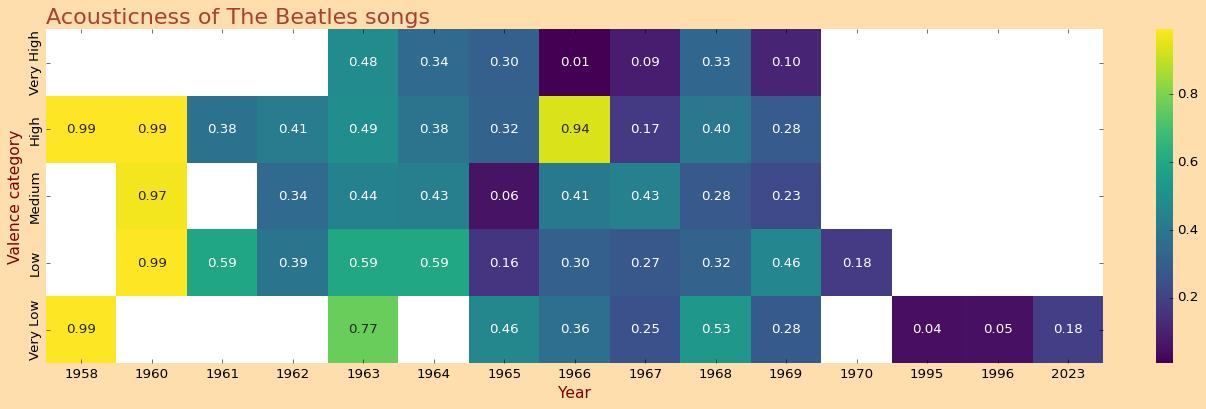

In [59]:
# sb.set_theme(rc={'figure.figsize': (15.7, 5.27)})
plt.figure(layout='constrained', facecolor='navajowhite', figsize=(15, 5))
sb.heatmap(data=pivot_table, annot=True, fmt='.2f', cmap='viridis');
plt.title('Acousticness of The Beatles songs', loc='left', color='maroon', alpha=0.7, size=20)
plt.xlabel('Year', size=14, color='maroon')
plt.ylabel('Valence category', size=14, color='maroon')
plt.show()

##### A fancier example
Average duration of songs over the years, represented as circles with sizes proportional to the numbers of songs.

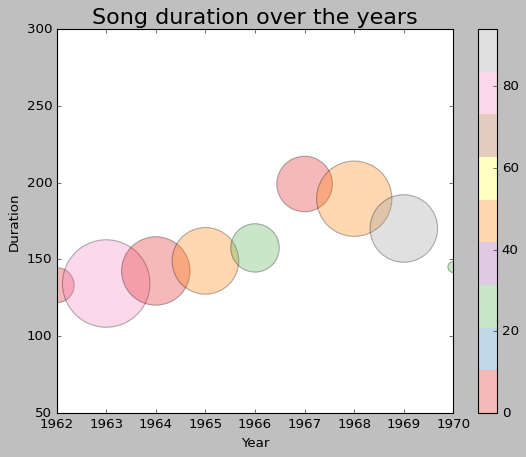

In [6]:
songs = pd.read_csv('../data/The Beatles songs, valence categories.csv')
songs_by_year = songs.groupby('Year')
years = np.sort(songs.Year.unique())
years

avg_duration = []
for year in years:
    avg_duration.append(np.mean(songs_by_year.get_group(year)['Duration']))
avg_duration = np.array(avg_duration)

rng = np.random.RandomState(370)

colors = rng.choice(100, size=len(years), replace=False)                    # random sample, no duplicates
# display(colors)

sizes = []
for year in years:
    sizes.append(len(songs_by_year.get_group(year)) * 100)                  # sizes proportional to the numbers of songs

plt.title('Song duration over the years', fontdict={'size': 20})
plt.xlabel('Year')
plt.ylabel('Duration')
plt.xlim(1962, 1970)
plt.ticklabel_format(useOffset=False)
plt.scatter(years, avg_duration,
            c=colors, s=sizes, alpha=0.3,                                   # alpha: the level of transparency
            cmap='Set1')                                                    # cmap: a pre-defined color map
plt.colorbar();                                                             # show color scale

# # Alternatively, but without showing the colorbar
# ax = plt.axes()
# ax.set(xlabel='Year', ylabel='Duration', xlim=(1962, 1970),
#        title='Song duration over the years')
# plt.ticklabel_format(useOffset=False)
# ax.scatter(years, avg_duration,
#            c=colors, s=sizes, alpha=0.3,                                    # alpha: the level of transparency
#            cmap='Set1');                                                    # cmap: a pre-defined color map